# Machine Data Analysis with Python, pandas, SQLite, and Matplotlib

## Project Overview

This notebook analyzes simulated production data from a SQLite database using Python and pandas.

The analysis focuses on machine operation, production cycles, alarms, energy readings, and production-order progress. The goal is to demonstrate how relational production data can be loaded, validated, summarized, and visualized in a simplified IT/OT data-analysis workflow.

The notebook includes:

- loading production tables from SQLite into pandas DataFrames
- inspecting database tables, columns, and row counts
- analyzing production-cycle durations
- analyzing alarm frequency, severity, and duration
- reviewing energy readings around a selected fault window
- creating machine-level operational summaries
- creating production-order progress summaries
- exporting summary tables
- generating Matplotlib visualizations

This project is based on sample production data and is intended to demonstrate the structure of an industrial data-analysis workflow. The results should be interpreted as a portfolio demonstration, not as production-grade machine-performance proof.

## Sample Scenario Description

This project uses a small synthetic production dataset to demonstrate an industrial IT/OT data-analysis workflow.

The sample scenario contains two machines and two production orders. Machine M001 represents a packaging machine with recorded production cycles, alarm events, energy readings, and machine-event logs. Machine M002 represents an assembly station with limited operational activity in the sample data.

The dataset intentionally contains only a small number of records. For example, only a few production cycles are recorded although the planned production quantity is much higher. Therefore, production progress values are not intended to represent real production performance. They are used only to demonstrate how production-order progress can be calculated from cycle records.

One critical alarm, ALM-304, is used as the main fault event. The notebook analyzes energy readings around this alarm window to demonstrate how alarm data and energy data can be compared in time. This analysis shows temporal association only. It does not prove that the alarm caused the energy change.

The purpose of the dataset is to demonstrate the workflow structure: loading data, validating tables, calculating KPIs, creating machine-level and production-order-level summaries, exporting results, visualizing selected metrics, and writing an engineering interpretation.


In [1]:
from pathlib import Path
import sqlite3
import pandas as pd

In [2]:
# ---------------------------------------------------------
# Detect project root and select the SQLite database
# ---------------------------------------------------------

CURRENT_WORKING_DIRECTORY = Path.cwd().resolve()

print("Current working directory:")
print(CURRENT_WORKING_DIRECTORY)


# ---------------------------------------------------------
# 1. Detect the project root
# ---------------------------------------------------------

candidate_roots = [
    CURRENT_WORKING_DIRECTORY,
    *CURRENT_WORKING_DIRECTORY.parents,
]

PROJECT_ROOT = None

for candidate_root in candidate_roots:
    has_notebooks_folder = (
        candidate_root / "notebooks"
    ).exists()

    has_project_structure = any(
        [
            (candidate_root / "data").exists(),
            (candidate_root / "outputs").exists(),
            (candidate_root / "sql").exists(),
            (candidate_root / "scripts").exists(),
        ]
    )

    if has_notebooks_folder and has_project_structure:
        PROJECT_ROOT = candidate_root
        break


if PROJECT_ROOT is None:
    if CURRENT_WORKING_DIRECTORY.name == "notebooks":
        PROJECT_ROOT = CURRENT_WORKING_DIRECTORY.parent
    else:
        PROJECT_ROOT = CURRENT_WORKING_DIRECTORY


print()
print("Detected project root:")
print(PROJECT_ROOT)


# ---------------------------------------------------------
# 2. Prefer the reproducible generated demo database
# ---------------------------------------------------------

preferred_database_path = (
    PROJECT_ROOT
    / "data"
    / "generated"
    / "demo_production.db"
)

DB_PATH = None

if preferred_database_path.exists():
    DB_PATH = preferred_database_path
    database_selection_method = (
        "Selected generated demo database from data/generated."
    )

else:
    database_file_patterns = [
        "*.db",
        "*.sqlite",
        "*.sqlite3",
    ]

    database_candidates = []

    for file_pattern in database_file_patterns:
        database_candidates.extend(
            PROJECT_ROOT.rglob(file_pattern)
        )

    database_candidates = [
        database_path
        for database_path in database_candidates
        if ".git" not in database_path.parts
        and ".venv" not in database_path.parts
        and "venv" not in database_path.parts
        and "__pycache__" not in database_path.parts
        and ".ipynb_checkpoints" not in database_path.parts
    ]

    database_candidates = sorted(
        database_candidates,
        key=lambda path: str(path).lower(),
    )

    print()
    print("SQLite database candidates found:")

    if database_candidates:
        for index, database_path in enumerate(database_candidates, start=1):
            print(
                f"{index}. "
                f"{database_path.relative_to(PROJECT_ROOT)}"
            )
    else:
        print("No SQLite database files were found.")

    if len(database_candidates) == 0:
        raise FileNotFoundError(
            "No SQLite database file was found inside the project folder. "
            "For the reproducible public project version, create the demo "
            "database first by running this command from the project root: "
            "python scripts/create_demo_database.py"
        )

    elif len(database_candidates) == 1:
        DB_PATH = database_candidates[0]
        database_selection_method = (
            "Selected the only SQLite database found in the project."
        )

    else:
        raise RuntimeError(
            "More than one SQLite database file was found and the preferred "
            "generated database does not exist. Run "
            "python scripts/create_demo_database.py or manually remove/ignore "
            "extra local database files before running this notebook."
        )


# ---------------------------------------------------------
# 3. Final database path verification
# ---------------------------------------------------------

print()
print("Database selection:")
print(database_selection_method)

print()
print("Selected database path:")
print(DB_PATH.relative_to(PROJECT_ROOT))

print()
print("Database exists:")
print(DB_PATH.exists())


Current working directory:
F:\production-data-model-mes-flow-public\notebooks

Detected project root:
F:\production-data-model-mes-flow-public

Database selection:
Selected generated demo database from data/generated.

Selected database path:
data\generated\demo_production.db

Database exists:
True


## 2. SQLite Connection and Table Discovery

This section connects to the SQLite production database and identifies the available database tables.

The table discovery step is important because the later analysis depends on specific production-data tables, including machines, production orders, machine events, cycle records, alarms, and energy readings.

Only user-defined tables are listed. Internal SQLite system tables are excluded.

In [3]:
# ---------------------------------------------------------
# Connect to SQLite and discover available tables
# ---------------------------------------------------------

tables_query = """
SELECT
    name AS table_name
FROM sqlite_master
WHERE type = 'table'
  AND name NOT LIKE 'sqlite_%'
ORDER BY name;
"""


with sqlite3.connect(DB_PATH) as connection:
    table_overview = pd.read_sql_query(
        tables_query,
        connection,
    )


table_names = table_overview["table_name"].tolist()


print("Database connection successful.")
print()
print("Tables found:")

for table_name in table_names:
    print(f"- {table_name}")


expected_tables = [
    "machines",
    "production_orders",
    "machine_events",
    "cycle_records",
    "alarm_events",
    "energy_readings",
]


missing_expected_tables = sorted(
    set(expected_tables).difference(table_names)
)


print()
print("Expected production tables check:")

if missing_expected_tables:
    print("Missing expected tables:")
    for table_name in missing_expected_tables:
        print(f"- {table_name}")
else:
    print("All expected production tables are available.")


display(table_overview)

Database connection successful.

Tables found:
- alarm_events
- cycle_records
- energy_readings
- machine_events
- machines
- production_orders

Expected production tables check:
All expected production tables are available.


,table_name
0,alarm_events
1,cycle_records
2,energy_readings
3,machine_events
4,machines
5,production_orders


## 3. Load Database Tables into pandas

This section loads each SQLite production table into a pandas DataFrame.

The loaded tables are stored in a dictionary named `dataframes`, where each key is a table name and each value is the corresponding pandas DataFrame.

This structure makes it easy to access individual tables during later analysis while keeping the original table names clear and traceable.

In [4]:
# ---------------------------------------------------------
# Load all discovered SQLite tables into pandas DataFrames
# ---------------------------------------------------------

if "table_names" not in globals():
    raise RuntimeError(
        "The table_names variable is missing. "
        "Run the SQLite table-discovery section before loading tables."
    )


dataframes = {}


with sqlite3.connect(DB_PATH) as connection:
    for table_name in table_names:
        query = f'SELECT * FROM "{table_name}";'

        dataframes[table_name] = pd.read_sql_query(
            query,
            connection,
        )


print("Tables loaded into pandas successfully.")
print()
print("Loaded DataFrames:")

for table_name, dataframe in dataframes.items():
    print(
        f"- {table_name}: "
        f"{dataframe.shape[0]} rows, "
        f"{dataframe.shape[1]} columns"
    )


expected_tables = [
    "machines",
    "production_orders",
    "machine_events",
    "cycle_records",
    "alarm_events",
    "energy_readings",
]


missing_loaded_tables = sorted(
    set(expected_tables).difference(dataframes.keys())
)


print()
print("Loaded table validation:")

if missing_loaded_tables:
    print("Missing loaded tables:")
    for table_name in missing_loaded_tables:
        print(f"- {table_name}")
else:
    print("All expected tables were loaded into pandas.")

Tables loaded into pandas successfully.

Loaded DataFrames:
- alarm_events: 3 rows, 14 columns
- cycle_records: 4 rows, 11 columns
- energy_readings: 4 rows, 11 columns
- machine_events: 5 rows, 11 columns
- machines: 2 rows, 10 columns
- production_orders: 2 rows, 13 columns

Loaded table validation:
All expected tables were loaded into pandas.


## 4. Table Overview and Data Validation

This section creates a compact overview of the loaded production tables.

The goal is to verify the size and structure of each table before performing analysis. The overview includes row counts, column counts, column names, and timestamp-related fields.

This validation step helps confirm that the imported data is suitable for later cycle-time, alarm, energy, production-order, and visualization analysis.

In [5]:
# ---------------------------------------------------------
# Create a structural overview of all loaded DataFrames
# ---------------------------------------------------------

if "dataframes" not in globals():
    raise RuntimeError(
        "The dataframes dictionary is missing. "
        "Run the table-loading section before creating the overview."
    )


table_summary_records = []

for table_name, dataframe in dataframes.items():

    column_names = dataframe.columns.tolist()

    timestamp_columns = [
        column_name
        for column_name in column_names
        if "time" in column_name.lower()
        or "timestamp" in column_name.lower()
        or column_name.lower().endswith("_utc")
    ]

    table_summary_records.append(
        {
            "table_name": table_name,
            "row_count": dataframe.shape[0],
            "column_count": dataframe.shape[1],
            "columns": ", ".join(column_names),
            "timestamp_columns": ", ".join(timestamp_columns)
            if timestamp_columns
            else "None detected",
        }
    )


table_summary = pd.DataFrame(table_summary_records)

table_summary = table_summary.sort_values(
    by="table_name",
    ascending=True,
).reset_index(drop=True)


print("Table overview created successfully.")
print()
print("Number of loaded tables:", len(dataframes))

display(table_summary)

Table overview created successfully.

Number of loaded tables: 6


,table_name,row_count,column_count,columns,timestamp_columns
0,alarm_events,3,14,"id, machine_db_id, order_db_id, alarm_code, al...","alarm_start_utc, alarm_end_utc, acknowledged_a..."
1,cycle_records,4,11,"id, machine_db_id, order_db_id, cycle_counter,...","cycle_start_utc, cycle_end_utc, cycle_time_ms,..."
2,energy_readings,4,11,"id, machine_db_id, order_db_id, reading_start_...","reading_start_utc, reading_end_utc, created_at..."
3,machine_events,5,11,"id, machine_db_id, order_db_id, event_time_utc...","event_time_utc, created_at_utc"
4,machines,2,10,"id, machine_id, machine_name, line_name, area_...","created_at_utc, updated_at_utc"
5,production_orders,2,13,"id, order_number, machine_db_id, product_code,...","planned_start_utc, planned_end_utc, actual_sta..."


## 5. Preview Key Tables

This section previews the first rows of the main production-data tables.

The purpose is to inspect the shape and content of the loaded data before performing detailed analysis. Previewing the tables helps confirm that the data contains machine master records, production orders, cycle records, alarm events, energy readings, and machine event logs.

Only a small number of rows is displayed from each table to keep the notebook readable.

In [6]:
# ---------------------------------------------------------
# Preview key production-data tables
# ---------------------------------------------------------

if "dataframes" not in globals():
    raise RuntimeError(
        "The dataframes dictionary is missing. "
        "Run the table-loading section before previewing tables."
    )


preview_tables = [
    "machines",
    "production_orders",
    "cycle_records",
    "alarm_events",
    "energy_readings",
    "machine_events",
]


missing_preview_tables = sorted(
    set(preview_tables).difference(dataframes.keys())
)


if missing_preview_tables:
    raise KeyError(
        "The following preview tables are missing from dataframes: "
        f"{missing_preview_tables}"
    )


pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)


for table_name in preview_tables:
    print("=" * 80)
    print(f"Preview: {table_name}")
    print("=" * 80)

    display(
        dataframes[table_name].head()
    )

Preview: machines


,id,machine_id,machine_name,line_name,area_name,plc_type,opcua_endpoint,is_active,created_at_utc,updated_at_utc
0,1,M001,Packaging Machine 1,Packaging Line,Production Area A,Siemens S7-1500,opc.tcp://machine01.local:4840,1,2026-06-13 23:26:39,None
1,2,M002,Assembly Station 1,Assembly Line,Production Area B,Siemens S7-1200,opc.tcp://machine02.local:4840,1,2026-06-13 23:26:39,None


Preview: production_orders


,id,order_number,machine_db_id,product_code,product_name,planned_quantity,order_status,planned_start_utc,planned_end_utc,actual_start_utc,actual_end_utc,created_at_utc,updated_at_utc
0,1,ORD-2026-001,1,PKG-A,Packaging Part A,1000,running,2026-06-01 06:00:00+00:00,2026-06-01 14:00:00+00:00,2026-06-01 06:05:00+00:00,None,2026-06-13 23:26:39,None
1,2,ORD-2026-002,2,ASM-B,Assembly Part B,500,planned,2026-06-01 14:00:00+00:00,2026-06-01 22:00:00+00:00,None,None,2026-06-13 23:26:39,None


Preview: cycle_records


...

,id,machine_db_id,order_db_id,alarm_code,alarm_message,alarm_category,severity,alarm_start_utc,alarm_end_utc,acknowledged_at_utc,acknowledged_by,source_tag,description,created_at_utc
0,1,1,1,ALM-120,Low air pressure warning,process,warning,2026-06-01 07:15:00+00:00,2026-06-01 07:18:00+00:00,None,None,Machine01.Alarms.ActiveAlarmCode,Temporary low air pressure warning during prod...,2026-06-13 23:26:39
1,2,1,1,ALM-304,Jam detected at packaging station,process,critical,2026-06-01 08:30:00+00:00,2026-06-01 08:42:00+00:00,2026-06-01 08:31:00+00:00,operator_01,Machine01.Alarms.ActiveAlarmCode,Critical process alarm during production order...,2026-06-13 23:26:39
2,3,2,2,ALM-010,Safety gate warning,safety,warning,2026-06-01 13:45:00+00:00,2026-06-01 13:48:00+00:00,2026-06-01 13:46:00+00:00,operator_02,Machine02.Alarms.ActiveAlarmCode,Safety warning during setup before planned pro...,2026-06-13 23:26:39


Preview: energy_readings


,id,machine_db_id,order_db_id,reading_start_utc,reading_end_utc,power_kw_avg,energy_kwh,reading_source,source_tag,description,created_at_utc
0,1,1,1,2026-06-01 06:05:00+00:00,2026-06-01 06:10:00+00:00,12.50,1.04,opcua,Machine01.Energy.Power_kW,Normal production energy reading for ORD-2026-...,2026-06-13 23:26:39
1,2,1,1,2026-06-01 08:25:00+00:00,2026-06-01 08:30:00+00:00,14.20,1.18,opcua,Machine01.Energy.Power_kW,Higher power reading shortly before ALM-304.,2026-06-13 23:26:39
2,3,1,1,2026-06-01 08:30:00+00:00,2026-06-01 08:35:00+00:00,2.00,0.17,opcua,Machine01.Energy.Power_kW,Lower power reading during the ALM-304 fault w...,2026-06-13 23:26:39
3,4,2,2,2026-06-01 13:45:00+00:00,2026-06-01 13:55:00+00:00,1.75,0.29,opcua,Machine02.Energy.Power_kW,Low energy reading during setup activity.,2026-06-13 23:26:39


Preview: machine_events


,id,machine_db_id,order_db_id,event_time_utc,event_type,event_value,event_source,severity,source_tag,description,created_at_utc
0,1,1,1,2026-06-01 06:05:00+00:00,state_change,automatic_production,PLC,info,Machine01.State.Mode,Machine changed to automatic production mode f...,2026-06-13 23:26:39
1,2,1,1,2026-06-01 08:30:00+00:00,fault,ALM-304,PLC,critical,Machine01.Events.FaultCode,Packaging jam fault event corresponding to ALM...,2026-06-13 23:26:39
2,3,1,1,2026-06-01 08:31:00+00:00,operator_action,alarm_acknowledged,HMI,info,Machine01.Operator.Action,Operator acknowledged ALM-304.,2026-06-13 23:26:39
3,4,1,1,2026-06-01 08:42:00+00:00,state_change,automatic_production_restarted,PLC,info,Machine01.State.Mode,Machine returned to automatic production after...,2026-06-13 23:26:39
4,5,2,2,2026-06-01 13:45:00+00:00,state_change,setup_mode,PLC,warning,Machine02.State.Mode,Assembly station setup state detected before p...,2026-06-13 23:26:39


## 6. Production-Cycle Duration Analysis

This section analyzes production-cycle records from the `cycle_records` table.

The goal is to validate cycle-time information by calculating cycle duration from the recorded start and end timestamps, then comparing the calculated duration with the stored `cycle_time_ms` value.

Only records with a produced quantity greater than zero are treated as production cycles for this analysis. Test cycles or records without produced output are excluded from the main cycle-time calculation.

The analysis also enriches cycle records with machine and production-order information so that cycle-time results can be interpreted in a production context.

In [7]:
# ---------------------------------------------------------
# Analyze production-cycle durations
# ---------------------------------------------------------

required_cycle_tables = [
    "cycle_records",
    "machines",
    "production_orders",
]

missing_cycle_tables = sorted(
    set(required_cycle_tables).difference(dataframes.keys())
)

if missing_cycle_tables:
    raise KeyError(
        "The following required tables are missing from dataframes: "
        f"{missing_cycle_tables}"
    )


# Create fresh working copies
cycle_records = dataframes["cycle_records"].copy()
machines = dataframes["machines"].copy()
production_orders = dataframes["production_orders"].copy()


# Keep only records that represent actual produced output
production_cycles = cycle_records[
    cycle_records["produced_quantity"] > 0
].copy()


# Convert timestamp columns to pandas datetime values
production_cycles["cycle_start_utc"] = pd.to_datetime(
    production_cycles["cycle_start_utc"],
    errors="coerce",
    utc=True,
)

production_cycles["cycle_end_utc"] = pd.to_datetime(
    production_cycles["cycle_end_utc"],
    errors="coerce",
    utc=True,
)


# Convert stored cycle time to numeric
production_cycles["cycle_time_ms"] = pd.to_numeric(
    production_cycles["cycle_time_ms"],
    errors="coerce",
)


# Calculate cycle duration from timestamps
production_cycles["calculated_cycle_time_ms"] = (
    production_cycles["cycle_end_utc"]
    - production_cycles["cycle_start_utc"]
).dt.total_seconds() * 1000


# Compare calculated duration with stored duration
production_cycles["duration_difference_ms"] = (
    production_cycles["calculated_cycle_time_ms"]
    - production_cycles["cycle_time_ms"]
)


# Keep only rows with valid calculated and stored cycle times
valid_cycle_duration_records = production_cycles.dropna(
    subset=[
        "cycle_time_ms",
        "calculated_cycle_time_ms",
    ]
).copy()


if valid_cycle_duration_records.empty:
    raise ValueError(
        "No valid production-cycle duration records are available for analysis."
    )


# Identify the slowest valid production cycle
slowest_cycle = valid_cycle_duration_records.sort_values(
    by="calculated_cycle_time_ms",
    ascending=False,
).head(1)


# Prepare machine lookup
machine_lookup = machines[
    [
        "id",
        "machine_id",
        "machine_name",
        "line_name",
        "area_name",
        "plc_type",
    ]
].copy()

machine_lookup = machine_lookup.rename(
    columns={
        "id": "machine_db_id",
    }
)


# Prepare production-order lookup
order_lookup = production_orders[
    [
        "id",
        "order_number",
        "product_code",
        "product_name",
        "planned_quantity",
        "order_status",
    ]
].copy()

order_lookup = order_lookup.rename(
    columns={
        "id": "order_db_id",
    }
)


# Merge cycle records with machine information
cycle_analysis_view = valid_cycle_duration_records.merge(
    machine_lookup,
    on="machine_db_id",
    how="left",
)


# Merge cycle records with production-order information
cycle_analysis_view = cycle_analysis_view.merge(
    order_lookup,
    on="order_db_id",
    how="left",
)


# Select readable analysis columns
cycle_analysis_columns = [
    "id",
    "machine_id",
    "machine_name",
    "order_number",
    "product_code",
    "cycle_counter",
    "produced_quantity",
    "cycle_start_utc",
    "cycle_end_utc",
    "cycle_time_ms",
    "calculated_cycle_time_ms",
    "duration_difference_ms",
    "description",
]


cycle_analysis_view = cycle_analysis_view[
    cycle_analysis_columns
].sort_values(
    by="cycle_start_utc",
    ascending=True,
).reset_index(drop=True)


print("Production-cycle duration analysis completed.")
print()
print("Total cycle records:", len(cycle_records))
print("Production cycles with produced quantity > 0:", len(production_cycles))
print("Valid duration records:", len(valid_cycle_duration_records))
print()
print("Cycle-time statistics in milliseconds:")

display(
    valid_cycle_duration_records[
        [
            "cycle_time_ms",
            "calculated_cycle_time_ms",
            "duration_difference_ms",
        ]
    ].describe()
)

print()
print("Slowest valid production cycle:")

display(slowest_cycle)

print()
print("Cycle analysis view:")

display(cycle_analysis_view)

Production-cycle duration analysis completed.

Total cycle records: 4
Production cycles with produced quantity > 0: 3
Valid duration records: 3

Cycle-time statistics in milliseconds:


,cycle_time_ms,calculated_cycle_time_ms,duration_difference_ms
count,3.000000,3.000000,3.0
mean,5333.333333,5333.333333,0.0
std,577.350269,577.350269,0.0
min,5000.000000,5000.000000,0.0
25%,5000.000000,5000.000000,0.0
50%,5000.000000,5000.000000,0.0
75%,5500.000000,5500.000000,0.0
max,6000.000000,6000.000000,0.0



Slowest valid production cycle:


,id,machine_db_id,order_db_id,cycle_counter,cycle_start_utc,cycle_end_utc,cycle_time_ms,produced_quantity,source_tag,description,created_at_utc,calculated_cycle_time_ms,duration_difference_ms
2,3,1,1,15243,2026-06-01 08:28:55+00:00,2026-06-01 08:29:01+00:00,6000,1,Machine01.Production.CycleCounter,Slower production cycle before the ALM-304 fau...,2026-06-13 23:26:39,6000.0,0.0



Cycle analysis view:


,id,machine_id,machine_name,order_number,product_code,cycle_counter,produced_quantity,cycle_start_utc,cycle_end_utc,cycle_time_ms,calculated_cycle_time_ms,duration_difference_ms,description
0,1,M001,Packaging Machine 1,ORD-2026-001,PKG-A,15241,1,2026-06-01 06:05:05+00:00,2026-06-01 06:05:10+00:00,5000,5000.0,0.0,Normal production cycle for ORD-2026-001.
1,2,M001,Packaging Machine 1,ORD-2026-001,PKG-A,15242,1,2026-06-01 06:05:10+00:00,2026-06-01 06:05:15+00:00,5000,5000.0,0.0,Normal production cycle for ORD-2026-001.
2,3,M001,Packaging Machine 1,ORD-2026-001,PKG-A,15243,1,2026-06-01 08:28:55+00:00,2026-06-01 08:29:01+00:00,6000,6000.0,0.0,Slower production cycle before the ALM-304 fau...


## 7. Alarm Analysis

This section analyzes alarm records from the `alarm_events` table.

The goal is to summarize alarm severity, alarm category, acknowledgement status, and alarm duration. Alarm start and end timestamps are converted into pandas datetime values so that alarm duration can be calculated in minutes.

The analysis also identifies critical alarms and enriches alarm records with machine information. This makes the alarm data easier to interpret in an industrial production context.

Alarm duration is not automatically equal to machine downtime. A machine may continue operating during some alarms, alarms may overlap, and an alarm can remain active after production has already stopped or resumed.

In [8]:
# ---------------------------------------------------------
# Analyze alarm events
# ---------------------------------------------------------

required_alarm_tables = [
    "alarm_events",
    "machines",
]

missing_alarm_tables = sorted(
    set(required_alarm_tables).difference(dataframes.keys())
)

if missing_alarm_tables:
    raise KeyError(
        "The following required tables are missing from dataframes: "
        f"{missing_alarm_tables}"
    )


# Create fresh working copies
alarm_events = dataframes["alarm_events"].copy()
machines = dataframes["machines"].copy()


# Validate required alarm columns
required_alarm_columns = [
    "id",
    "machine_db_id",
    "alarm_code",
    "alarm_category",
    "severity",
    "alarm_start_utc",
    "alarm_end_utc",
    "acknowledged_at_utc",
    "acknowledged_by",
    "description",
]

missing_alarm_columns = sorted(
    set(required_alarm_columns).difference(alarm_events.columns)
)

if missing_alarm_columns:
    raise KeyError(
        "The alarm_events table is missing required columns: "
        f"{missing_alarm_columns}"
    )


# ---------------------------------------------------------
# 1. Basic alarm summaries
# ---------------------------------------------------------

severity_counts = (
    alarm_events["severity"]
    .fillna("unknown")
    .astype("string")
    .str.lower()
    .value_counts()
    .rename_axis("severity")
    .reset_index(name="alarm_count")
)


category_counts = (
    alarm_events["alarm_category"]
    .fillna("unknown")
    .astype("string")
    .str.lower()
    .value_counts()
    .rename_axis("alarm_category")
    .reset_index(name="alarm_count")
)


alarm_events["is_acknowledged"] = (
    alarm_events["acknowledged_at_utc"]
    .notna()
)

acknowledgement_counts = (
    alarm_events["is_acknowledged"]
    .value_counts()
    .rename_axis("is_acknowledged")
    .reset_index(name="alarm_count")
)


# ---------------------------------------------------------
# 2. Convert alarm timestamps
# ---------------------------------------------------------

alarm_events["alarm_start_utc"] = pd.to_datetime(
    alarm_events["alarm_start_utc"],
    errors="coerce",
    utc=True,
)

alarm_events["alarm_end_utc"] = pd.to_datetime(
    alarm_events["alarm_end_utc"],
    errors="coerce",
    utc=True,
)

alarm_events["acknowledged_at_utc"] = pd.to_datetime(
    alarm_events["acknowledged_at_utc"],
    errors="coerce",
    utc=True,
)


# ---------------------------------------------------------
# 3. Calculate alarm duration in minutes
# ---------------------------------------------------------

alarm_events["alarm_duration_minutes"] = (
    alarm_events["alarm_end_utc"]
    - alarm_events["alarm_start_utc"]
).dt.total_seconds() / 60


valid_alarm_duration_records = alarm_events.dropna(
    subset=[
        "alarm_start_utc",
        "alarm_end_utc",
        "alarm_duration_minutes",
    ]
).copy()


negative_alarm_durations = valid_alarm_duration_records[
    valid_alarm_duration_records["alarm_duration_minutes"] < 0
].copy()


if not negative_alarm_durations.empty:
    raise ValueError(
        "One or more alarms have an end timestamp earlier than "
        "the start timestamp. Review the alarm timestamp data before analysis."
    )


if valid_alarm_duration_records.empty:
    raise ValueError(
        "No valid alarm-duration records are available for analysis."
    )


longest_alarm = valid_alarm_duration_records.sort_values(
    by="alarm_duration_minutes",
    ascending=False,
).head(1)


# ---------------------------------------------------------
# 4. Merge alarms with machine information
# ---------------------------------------------------------

machine_lookup_for_alarms = machines[
    [
        "id",
        "machine_id",
        "machine_name",
        "line_name",
        "area_name",
        "plc_type",
    ]
].copy()

machine_lookup_for_alarms = machine_lookup_for_alarms.rename(
    columns={
        "id": "machine_db_id",
    }
)


alarm_analysis_view = alarm_events.merge(
    machine_lookup_for_alarms,
    on="machine_db_id",
    how="left",
)


alarm_analysis_columns = [
    "id",
    "machine_id",
    "machine_name",
    "alarm_code",
    "alarm_category",
    "severity",
    "alarm_start_utc",
    "alarm_end_utc",
    "alarm_duration_minutes",
    "is_acknowledged",
    "acknowledged_at_utc",
    "acknowledged_by",
    "description",
]


alarm_analysis_view = alarm_analysis_view[
    alarm_analysis_columns
].sort_values(
    by="alarm_start_utc",
    ascending=True,
).reset_index(drop=True)


# ---------------------------------------------------------
# 5. Filter critical alarms robustly
# ---------------------------------------------------------

critical_alarms = alarm_analysis_view[
    alarm_analysis_view["severity"]
    .astype("string")
    .str.lower()
    .eq("critical")
].copy()


# ---------------------------------------------------------
# 6. Inspect ALM-304
# ---------------------------------------------------------

alm304_alarm = alarm_analysis_view[
    alarm_analysis_view["alarm_code"]
    .astype("string")
    .str.strip()
    .str.upper()
    .eq("ALM-304")
].copy()


print("Alarm analysis completed.")
print()
print("Total alarm records:", len(alarm_events))
print("Valid alarm-duration records:", len(valid_alarm_duration_records))
print("Critical alarm records:", len(critical_alarms))
print("ALM-304 records found:", len(alm304_alarm))

print()
print("Alarm count by severity:")
display(severity_counts)

print()
print("Alarm count by category:")
display(category_counts)

print()
print("Alarm acknowledgement summary:")
display(acknowledgement_counts)

print()
print("Alarm-duration statistics in minutes:")
display(
    valid_alarm_duration_records[
        ["alarm_duration_minutes"]
    ].describe()
)

print()
print("Longest valid alarm:")
display(longest_alarm)

print()
print("Critical alarms:")
display(critical_alarms)

print()
print("ALM-304 alarm details:")
display(alm304_alarm)

print()
print("Alarm analysis view:")
display(alarm_analysis_view)

Alarm analysis completed.

Total alarm records: 3
Valid alarm-duration records: 3
Critical alarm records: 1
ALM-304 records found: 1

Alarm count by severity:


,severity,alarm_count
0,warning,2
1,critical,1



Alarm count by category:


,alarm_category,alarm_count
0,process,2
1,safety,1



Alarm acknowledgement summary:


...

,id,machine_id,machine_name,alarm_code,alarm_category,severity,alarm_start_utc,alarm_end_utc,alarm_duration_minutes,is_acknowledged,acknowledged_at_utc,acknowledged_by,description
1,2,M001,Packaging Machine 1,ALM-304,process,critical,2026-06-01 08:30:00+00:00,2026-06-01 08:42:00+00:00,12.0,True,2026-06-01 08:31:00+00:00,operator_01,Critical process alarm during production order...



ALM-304 alarm details:


,id,machine_id,machine_name,alarm_code,alarm_category,severity,alarm_start_utc,alarm_end_utc,alarm_duration_minutes,is_acknowledged,acknowledged_at_utc,acknowledged_by,description
1,2,M001,Packaging Machine 1,ALM-304,process,critical,2026-06-01 08:30:00+00:00,2026-06-01 08:42:00+00:00,12.0,True,2026-06-01 08:31:00+00:00,operator_01,Critical process alarm during production order...



Alarm analysis view:


,id,machine_id,machine_name,alarm_code,alarm_category,severity,alarm_start_utc,alarm_end_utc,alarm_duration_minutes,is_acknowledged,acknowledged_at_utc,acknowledged_by,description
0,1,M001,Packaging Machine 1,ALM-120,process,warning,2026-06-01 07:15:00+00:00,2026-06-01 07:18:00+00:00,3.0,False,NaT,None,Temporary low air pressure warning during prod...
1,2,M001,Packaging Machine 1,ALM-304,process,critical,2026-06-01 08:30:00+00:00,2026-06-01 08:42:00+00:00,12.0,True,2026-06-01 08:31:00+00:00,operator_01,Critical process alarm during production order...
2,3,M002,Assembly Station 1,ALM-010,safety,warning,2026-06-01 13:45:00+00:00,2026-06-01 13:48:00+00:00,3.0,True,2026-06-01 13:46:00+00:00,operator_02,Safety warning during setup before planned pro...


## 8. Energy Analysis Around Fault Window

This section analyzes energy readings around the ALM-304 fault window.

The ALM-304 alarm is used to identify the affected machine and the recorded fault interval. Energy readings for the same machine are then converted into timestamp-based intervals and classified according to their relationship to the fault window.

The analysis compares average power and recorded energy before, during or overlapping, and after the selected alarm interval.

This section shows temporal association only. A change in power near the alarm window does not prove that the alarm caused the change. Additional machine-state, control-sequence, operator-action, and production-context data would be required for a stronger root-cause conclusion.

In [9]:
# ---------------------------------------------------------
# Analyze energy readings around the ALM-304 fault window
# ---------------------------------------------------------

required_energy_tables = [
    "energy_readings",
    "alarm_events",
    "machines",
]

missing_energy_tables = sorted(
    set(required_energy_tables).difference(dataframes.keys())
)

if missing_energy_tables:
    raise KeyError(
        "The following required tables are missing from dataframes: "
        f"{missing_energy_tables}"
    )


# Create fresh working copies
energy_readings = dataframes["energy_readings"].copy()
alarm_events_for_energy = dataframes["alarm_events"].copy()
machines = dataframes["machines"].copy()


# ---------------------------------------------------------
# 1. Validate required columns
# ---------------------------------------------------------

required_energy_columns = [
    "id",
    "machine_db_id",
    "order_db_id",
    "reading_start_utc",
    "reading_end_utc",
    "power_kw_avg",
    "energy_kwh",
    "reading_source",
    "source_tag",
    "description",
]

required_alarm_columns_for_energy = [
    "machine_db_id",
    "alarm_code",
    "alarm_start_utc",
    "alarm_end_utc",
]

missing_energy_columns = sorted(
    set(required_energy_columns).difference(energy_readings.columns)
)

missing_alarm_columns_for_energy = sorted(
    set(required_alarm_columns_for_energy).difference(
        alarm_events_for_energy.columns
    )
)

if missing_energy_columns:
    raise KeyError(
        "The energy_readings table is missing required columns: "
        f"{missing_energy_columns}"
    )

if missing_alarm_columns_for_energy:
    raise KeyError(
        "The alarm_events table is missing required columns: "
        f"{missing_alarm_columns_for_energy}"
    )


# ---------------------------------------------------------
# 2. Locate the ALM-304 alarm
# ---------------------------------------------------------

normalized_alarm_codes = (
    alarm_events_for_energy["alarm_code"]
    .astype("string")
    .str.strip()
    .str.upper()
)

alm304_fault_records = alarm_events_for_energy[
    normalized_alarm_codes.eq("ALM-304")
].copy()

if len(alm304_fault_records) != 1:
    raise ValueError(
        "Exactly one ALM-304 alarm record is expected for this analysis, "
        f"but {len(alm304_fault_records)} records were found."
    )


alm304_fault_record = alm304_fault_records.iloc[0].copy()

fault_machine_db_id = alm304_fault_record["machine_db_id"]

fault_start = pd.to_datetime(
    alm304_fault_record["alarm_start_utc"],
    errors="coerce",
    utc=True,
)

fault_end = pd.to_datetime(
    alm304_fault_record["alarm_end_utc"],
    errors="coerce",
    utc=True,
)


if pd.isna(fault_machine_db_id):
    raise ValueError(
        "The ALM-304 alarm record does not contain a valid machine_db_id."
    )

if pd.isna(fault_start) or pd.isna(fault_end):
    raise ValueError(
        "The ALM-304 alarm record does not contain valid start and end timestamps."
    )

if fault_end < fault_start:
    raise ValueError(
        "The ALM-304 alarm end timestamp is earlier than the start timestamp."
    )


# ---------------------------------------------------------
# 3. Prepare energy readings for the affected machine
# ---------------------------------------------------------

energy_readings["reading_start_utc"] = pd.to_datetime(
    energy_readings["reading_start_utc"],
    errors="coerce",
    utc=True,
)

energy_readings["reading_end_utc"] = pd.to_datetime(
    energy_readings["reading_end_utc"],
    errors="coerce",
    utc=True,
)

energy_readings["power_kw_avg"] = pd.to_numeric(
    energy_readings["power_kw_avg"],
    errors="coerce",
)

energy_readings["energy_kwh"] = pd.to_numeric(
    energy_readings["energy_kwh"],
    errors="coerce",
)


affected_machine_energy = energy_readings[
    energy_readings["machine_db_id"].eq(fault_machine_db_id)
].copy()


valid_energy_intervals = affected_machine_energy.dropna(
    subset=[
        "reading_start_utc",
        "reading_end_utc",
        "power_kw_avg",
        "energy_kwh",
    ]
).copy()


invalid_energy_intervals = valid_energy_intervals[
    valid_energy_intervals["reading_end_utc"]
    < valid_energy_intervals["reading_start_utc"]
].copy()


if not invalid_energy_intervals.empty:
    raise ValueError(
        "One or more energy readings have an end timestamp earlier than "
        "the start timestamp. Review the energy interval data before analysis."
    )


if valid_energy_intervals.empty:
    raise ValueError(
        "No valid energy readings are available for the machine affected by ALM-304."
    )


# ---------------------------------------------------------
# 4. Calculate interval midpoint and classify fault-window phase
# ---------------------------------------------------------

valid_energy_intervals["interval_midpoint_utc"] = (
    valid_energy_intervals["reading_start_utc"]
    + (
        valid_energy_intervals["reading_end_utc"]
        - valid_energy_intervals["reading_start_utc"]
    ) / 2
)


def classify_fault_window_phase(row):
    """
    Classify an energy-reading interval relative to the ALM-304 fault window.
    """

    interval_start = row["reading_start_utc"]
    interval_end = row["reading_end_utc"]

    if interval_end <= fault_start:
        return "before_fault_window"

    if interval_start >= fault_end:
        return "after_fault_window"

    if interval_start < fault_end and interval_end > fault_start:
        return "overlapping_fault_window"

    return "unclassified"


valid_energy_intervals["fault_window_phase"] = (
    valid_energy_intervals.apply(
        classify_fault_window_phase,
        axis=1,
    )
)


phase_order = [
    "before_fault_window",
    "overlapping_fault_window",
    "after_fault_window",
    "unclassified",
]

valid_energy_intervals["fault_window_phase"] = pd.Categorical(
    valid_energy_intervals["fault_window_phase"],
    categories=phase_order,
    ordered=True,
)


# ---------------------------------------------------------
# 5. Merge with machine information
# ---------------------------------------------------------

machine_lookup_for_energy = machines[
    [
        "id",
        "machine_id",
        "machine_name",
        "line_name",
        "area_name",
        "plc_type",
    ]
].copy()

machine_lookup_for_energy = machine_lookup_for_energy.rename(
    columns={
        "id": "machine_db_id",
    }
)


energy_fault_analysis_view = valid_energy_intervals.merge(
    machine_lookup_for_energy,
    on="machine_db_id",
    how="left",
)


energy_fault_analysis_columns = [
    "id",
    "machine_id",
    "machine_name",
    "reading_start_utc",
    "reading_end_utc",
    "interval_midpoint_utc",
    "fault_window_phase",
    "power_kw_avg",
    "energy_kwh",
    "reading_source",
    "source_tag",
    "description",
]


energy_fault_analysis_view = energy_fault_analysis_view[
    energy_fault_analysis_columns
].sort_values(
    by="reading_start_utc",
    ascending=True,
).reset_index(drop=True)


# ---------------------------------------------------------
# 6. Summarize energy readings by fault-window phase
# ---------------------------------------------------------

energy_summary_by_phase = (
    energy_fault_analysis_view
    .groupby(
        "fault_window_phase",
        observed=True,
    )
    .agg(
        record_count=("id", "count"),
        mean_power_kw=("power_kw_avg", "mean"),
        min_power_kw=("power_kw_avg", "min"),
        max_power_kw=("power_kw_avg", "max"),
        total_energy_kwh=("energy_kwh", "sum"),
    )
    .reset_index()
    .sort_values(
        by="fault_window_phase",
        ascending=True,
    )
)


overlapping_fault_readings = energy_fault_analysis_view[
    energy_fault_analysis_view["fault_window_phase"]
    .astype("string")
    .eq("overlapping_fault_window")
].copy()


print("Energy analysis around ALM-304 completed.")
print()
print("ALM-304 records found:", len(alm304_fault_records))
print("Affected machine database ID:", fault_machine_db_id)
print("Fault start:", fault_start)
print("Fault end:", fault_end)
print("Energy readings for affected machine:", len(affected_machine_energy))
print("Valid energy interval records:", len(valid_energy_intervals))
print("Energy readings overlapping fault window:", len(overlapping_fault_readings))

print()
print("Energy summary by fault-window phase:")
display(energy_summary_by_phase)

print()
print("Energy readings overlapping the ALM-304 fault window:")
display(overlapping_fault_readings)

print()
print("Energy fault analysis view:")
display(energy_fault_analysis_view)

Energy analysis around ALM-304 completed.

ALM-304 records found: 1
Affected machine database ID: 1
Fault start: 2026-06-01 08:30:00+00:00
Fault end: 2026-06-01 08:42:00+00:00
Energy readings for affected machine: 3
Valid energy interval records: 3
Energy readings overlapping fault window: 1

Energy summary by fault-window phase:


,fault_window_phase,record_count,mean_power_kw,min_power_kw,max_power_kw,total_energy_kwh
0,before_fault_window,2,13.35,12.5,14.2,2.22
1,overlapping_fault_window,1,2.00,2.0,2.0,0.17



Energy readings overlapping the ALM-304 fault window:


,id,machine_id,machine_name,reading_start_utc,reading_end_utc,interval_midpoint_utc,fault_window_phase,power_kw_avg,energy_kwh,reading_source,source_tag,description
2,3,M001,Packaging Machine 1,2026-06-01 08:30:00+00:00,2026-06-01 08:35:00+00:00,2026-06-01 08:32:30+00:00,overlapping_fault_window,2.0,0.17,opcua,Machine01.Energy.Power_kW,Lower power reading during the ALM-304 fault w...



Energy fault analysis view:


,id,machine_id,machine_name,reading_start_utc,reading_end_utc,interval_midpoint_utc,fault_window_phase,power_kw_avg,energy_kwh,reading_source,source_tag,description
0,1,M001,Packaging Machine 1,2026-06-01 06:05:00+00:00,2026-06-01 06:10:00+00:00,2026-06-01 06:07:30+00:00,before_fault_window,12.5,1.04,opcua,Machine01.Energy.Power_kW,Normal production energy reading for ORD-2026-...
1,2,M001,Packaging Machine 1,2026-06-01 08:25:00+00:00,2026-06-01 08:30:00+00:00,2026-06-01 08:27:30+00:00,before_fault_window,14.2,1.18,opcua,Machine01.Energy.Power_kW,Higher power reading shortly before ALM-304.
2,3,M001,Packaging Machine 1,2026-06-01 08:30:00+00:00,2026-06-01 08:35:00+00:00,2026-06-01 08:32:30+00:00,overlapping_fault_window,2.0,0.17,opcua,Machine01.Energy.Power_kW,Lower power reading during the ALM-304 fault w...


## 9. Machine-Level Operational Summary

This section creates a machine-level operational summary by combining information from cycle records, alarm events, energy readings, and machine event logs.

The goal is to build one compact view per machine that summarizes production activity, alarm behavior, energy usage, and event activity.

The resulting table is stored as `machine_operational_view` and exported as a CSV file. This view can be used later for reporting, visualization, and portfolio-level explanation of the production-data model.

The summary is based on sample data and should be interpreted as a demonstration of the analysis workflow, not as a real production-performance benchmark.

In [10]:
# ---------------------------------------------------------
# Create machine-level operational summary
# ---------------------------------------------------------

required_machine_summary_tables = [
    "machines",
    "cycle_records",
    "alarm_events",
    "energy_readings",
    "machine_events",
]

missing_machine_summary_tables = sorted(
    set(required_machine_summary_tables).difference(dataframes.keys())
)

if missing_machine_summary_tables:
    raise KeyError(
        "The following required tables are missing from dataframes: "
        f"{missing_machine_summary_tables}"
    )


# Create fresh working copies
machines = dataframes["machines"].copy()
cycle_records = dataframes["cycle_records"].copy()
alarm_events = dataframes["alarm_events"].copy()
energy_readings = dataframes["energy_readings"].copy()
machine_events = dataframes["machine_events"].copy()


# ---------------------------------------------------------
# 1. Prepare machine base table
# ---------------------------------------------------------

machine_base = machines[
    [
        "id",
        "machine_id",
        "machine_name",
        "line_name",
        "area_name",
        "plc_type",
        "opcua_endpoint",
        "is_active",
    ]
].copy()

machine_base = machine_base.rename(
    columns={
        "id": "machine_db_id",
    }
)


# ---------------------------------------------------------
# 2. Cycle summary by machine
# ---------------------------------------------------------

cycle_records["produced_quantity"] = pd.to_numeric(
    cycle_records["produced_quantity"],
    errors="coerce",
)

cycle_records["cycle_time_ms"] = pd.to_numeric(
    cycle_records["cycle_time_ms"],
    errors="coerce",
)

production_cycle_records = cycle_records[
    cycle_records["produced_quantity"] > 0
].copy()


cycle_record_count_summary = (
    cycle_records
    .groupby("machine_db_id")
    .agg(
        cycle_record_count=("id", "count"),
    )
    .reset_index()
)


production_cycle_summary = (
    production_cycle_records
    .groupby("machine_db_id")
    .agg(
        production_cycle_count=("id", "count"),
        total_produced_quantity=("produced_quantity", "sum"),
        mean_cycle_time_ms=("cycle_time_ms", "mean"),
        max_cycle_time_ms=("cycle_time_ms", "max"),
    )
    .reset_index()
)


cycle_summary = cycle_record_count_summary.merge(
    production_cycle_summary,
    on="machine_db_id",
    how="left",
)


# ---------------------------------------------------------
# 3. Alarm summary by machine
# ---------------------------------------------------------

alarm_events["severity_normalized"] = (
    alarm_events["severity"]
    .astype("string")
    .str.strip()
    .str.lower()
)

alarm_events["is_critical_alarm"] = (
    alarm_events["severity_normalized"].eq("critical")
)

alarm_events["is_warning_alarm"] = (
    alarm_events["severity_normalized"].eq("warning")
)

alarm_events["is_acknowledged"] = (
    alarm_events["acknowledged_at_utc"].notna()
)


alarm_events["alarm_start_utc"] = pd.to_datetime(
    alarm_events["alarm_start_utc"],
    errors="coerce",
    utc=True,
)

alarm_events["alarm_end_utc"] = pd.to_datetime(
    alarm_events["alarm_end_utc"],
    errors="coerce",
    utc=True,
)


alarm_events["alarm_duration_minutes"] = (
    alarm_events["alarm_end_utc"]
    - alarm_events["alarm_start_utc"]
).dt.total_seconds() / 60


alarm_summary = (
    alarm_events
    .groupby("machine_db_id")
    .agg(
        total_alarm_count=("id", "count"),
        critical_alarm_count=("is_critical_alarm", "sum"),
        warning_alarm_count=("is_warning_alarm", "sum"),
        acknowledged_alarm_count=("is_acknowledged", "sum"),
        total_alarm_duration_minutes=("alarm_duration_minutes", "sum"),
        max_alarm_duration_minutes=("alarm_duration_minutes", "max"),
    )
    .reset_index()
)


# ---------------------------------------------------------
# 4. Energy summary by machine
# ---------------------------------------------------------

energy_readings["power_kw_avg"] = pd.to_numeric(
    energy_readings["power_kw_avg"],
    errors="coerce",
)

energy_readings["energy_kwh"] = pd.to_numeric(
    energy_readings["energy_kwh"],
    errors="coerce",
)


energy_summary = (
    energy_readings
    .groupby("machine_db_id")
    .agg(
        energy_reading_count=("id", "count"),
        mean_power_kw=("power_kw_avg", "mean"),
        max_power_kw=("power_kw_avg", "max"),
        total_energy_kwh=("energy_kwh", "sum"),
    )
    .reset_index()
)


# ---------------------------------------------------------
# 5. Machine-event summary by machine
# ---------------------------------------------------------

machine_events["event_time_utc"] = pd.to_datetime(
    machine_events["event_time_utc"],
    errors="coerce",
    utc=True,
)

machine_events["event_type_normalized"] = (
    machine_events["event_type"]
    .astype("string")
    .str.strip()
    .str.lower()
)

machine_events["severity_normalized"] = (
    machine_events["severity"]
    .astype("string")
    .str.strip()
    .str.lower()
)

machine_events["is_fault_event"] = (
    machine_events["event_type_normalized"].eq("fault")
)

machine_events["is_state_change_event"] = (
    machine_events["event_type_normalized"].eq("state_change")
)

machine_events["is_operator_action_event"] = (
    machine_events["event_type_normalized"].eq("operator_action")
)


event_summary = (
    machine_events
    .groupby("machine_db_id")
    .agg(
        machine_event_count=("id", "count"),
        fault_event_count=("is_fault_event", "sum"),
        state_change_event_count=("is_state_change_event", "sum"),
        operator_action_event_count=("is_operator_action_event", "sum"),
        first_event_time_utc=("event_time_utc", "min"),
        last_event_time_utc=("event_time_utc", "max"),
    )
    .reset_index()
)


# ---------------------------------------------------------
# 6. Combine all summaries into one machine-level view
# ---------------------------------------------------------

machine_operational_view = (
    machine_base
    .merge(
        cycle_summary,
        on="machine_db_id",
        how="left",
    )
    .merge(
        alarm_summary,
        on="machine_db_id",
        how="left",
    )
    .merge(
        energy_summary,
        on="machine_db_id",
        how="left",
    )
    .merge(
        event_summary,
        on="machine_db_id",
        how="left",
    )
)


count_columns = [
    "cycle_record_count",
    "production_cycle_count",
    "total_produced_quantity",
    "total_alarm_count",
    "critical_alarm_count",
    "warning_alarm_count",
    "acknowledged_alarm_count",
    "energy_reading_count",
    "machine_event_count",
    "fault_event_count",
    "state_change_event_count",
    "operator_action_event_count",
]

for column_name in count_columns:
    if column_name in machine_operational_view.columns:
        machine_operational_view[column_name] = (
            machine_operational_view[column_name]
            .fillna(0)
            .astype(int)
        )


sum_columns = [
    "total_alarm_duration_minutes",
    "total_energy_kwh",
]

for column_name in sum_columns:
    if column_name in machine_operational_view.columns:
        machine_operational_view[column_name] = (
            machine_operational_view[column_name]
            .fillna(0)
        )


round_columns = [
    "mean_cycle_time_ms",
    "max_cycle_time_ms",
    "total_alarm_duration_minutes",
    "max_alarm_duration_minutes",
    "mean_power_kw",
    "max_power_kw",
    "total_energy_kwh",
]

for column_name in round_columns:
    if column_name in machine_operational_view.columns:
        machine_operational_view[column_name] = (
            machine_operational_view[column_name]
            .round(2)
        )


machine_operational_view = machine_operational_view.sort_values(
    by="machine_id",
    ascending=True,
).reset_index(drop=True)


# ---------------------------------------------------------
# 7. Export machine-level summary
# ---------------------------------------------------------

output_tables_dir = PROJECT_ROOT / "outputs" / "tables"
output_tables_dir.mkdir(
    parents=True,
    exist_ok=True,
)

machine_operational_summary_path = (
    output_tables_dir / "machine_operational_summary.csv"
)

machine_operational_view.to_csv(
    machine_operational_summary_path,
    index=False,
)


print("Machine-level operational summary created successfully.")
print()
print("Machines summarized:", len(machine_operational_view))
print("Output file:")
print(machine_operational_summary_path.relative_to(PROJECT_ROOT))

display(machine_operational_view)

Machine-level operational summary created successfully.

Machines summarized: 2
Output file:
outputs\tables\machine_operational_summary.csv


,machine_db_id,machine_id,machine_name,line_name,area_name,plc_type,opcua_endpoint,is_active,cycle_record_count,production_cycle_count,total_produced_quantity,mean_cycle_time_ms,max_cycle_time_ms,total_alarm_count,critical_alarm_count,warning_alarm_count,acknowledged_alarm_count,total_alarm_duration_minutes,max_alarm_duration_minutes,energy_reading_count,mean_power_kw,max_power_kw,total_energy_kwh,machine_event_count,fault_event_count,state_change_event_count,operator_action_event_count,first_event_time_utc,last_event_time_utc
0,1,M001,Packaging Machine 1,Packaging Line,Production Area A,Siemens S7-1500,opc.tcp://machine01.local:4840,1,3,3,3,5333.33,6000.0,2,1,1,1,15.0,12.0,3,9.57,14.20,2.39,4,1,2,1,2026-06-01 06:05:00+00:00,2026-06-01 08:42:00+00:00
1,2,M002,Assembly Station 1,Assembly Line,Production Area B,Siemens S7-1200,opc.tcp://machine02.local:4840,1,1,0,0,NaN,NaN,1,0,1,1,3.0,3.0,1,1.75,1.75,0.29,1,0,1,0,2026-06-01 13:45:00+00:00,2026-06-01 13:45:00+00:00


## 10. Production-Order Summary

This section creates a production-order-level summary by combining production order data with cycle records, alarms, energy readings, machine events, and machine master data.

The goal is to build one compact view per production order that summarizes planned quantity, produced quantity, production progress, cycle activity, alarm activity, energy usage, and related machine events.

The resulting table is stored as `production_order_view` and exported as a CSV file. This view can be used later for reporting, visualization, and explaining how production-order data can be connected with operational machine data.

The summary is based on sample data and should be interpreted as a demonstration of the analysis workflow, not as a real production-performance report.

In [11]:
# ---------------------------------------------------------
# Create production-order-level summary
# ---------------------------------------------------------

required_order_summary_tables = [
    "production_orders",
    "machines",
    "cycle_records",
    "alarm_events",
    "energy_readings",
    "machine_events",
]

missing_order_summary_tables = sorted(
    set(required_order_summary_tables).difference(dataframes.keys())
)

if missing_order_summary_tables:
    raise KeyError(
        "The following required tables are missing from dataframes: "
        f"{missing_order_summary_tables}"
    )


# Create fresh working copies
production_orders = dataframes["production_orders"].copy()
machines = dataframes["machines"].copy()
cycle_records = dataframes["cycle_records"].copy()
alarm_events = dataframes["alarm_events"].copy()
energy_readings = dataframes["energy_readings"].copy()
machine_events = dataframes["machine_events"].copy()


# ---------------------------------------------------------
# 1. Prepare production-order base table
# ---------------------------------------------------------

production_orders["planned_quantity"] = pd.to_numeric(
    production_orders["planned_quantity"],
    errors="coerce",
)

production_orders["planned_start_utc"] = pd.to_datetime(
    production_orders["planned_start_utc"],
    errors="coerce",
    utc=True,
)

production_orders["planned_end_utc"] = pd.to_datetime(
    production_orders["planned_end_utc"],
    errors="coerce",
    utc=True,
)

production_orders["actual_start_utc"] = pd.to_datetime(
    production_orders["actual_start_utc"],
    errors="coerce",
    utc=True,
)

production_orders["actual_end_utc"] = pd.to_datetime(
    production_orders["actual_end_utc"],
    errors="coerce",
    utc=True,
)


production_orders["planned_duration_hours"] = (
    production_orders["planned_end_utc"]
    - production_orders["planned_start_utc"]
).dt.total_seconds() / 3600


production_orders["actual_duration_hours"] = (
    production_orders["actual_end_utc"]
    - production_orders["actual_start_utc"]
).dt.total_seconds() / 3600


order_base = production_orders[
    [
        "id",
        "order_number",
        "machine_db_id",
        "product_code",
        "product_name",
        "planned_quantity",
        "order_status",
        "planned_start_utc",
        "planned_end_utc",
        "actual_start_utc",
        "actual_end_utc",
        "planned_duration_hours",
        "actual_duration_hours",
    ]
].copy()

order_base = order_base.rename(
    columns={
        "id": "order_db_id",
    }
)


# ---------------------------------------------------------
# 2. Add machine information to production orders
# ---------------------------------------------------------

machine_lookup_for_orders = machines[
    [
        "id",
        "machine_id",
        "machine_name",
        "line_name",
        "area_name",
        "plc_type",
    ]
].copy()

machine_lookup_for_orders = machine_lookup_for_orders.rename(
    columns={
        "id": "machine_db_id",
    }
)


order_base = order_base.merge(
    machine_lookup_for_orders,
    on="machine_db_id",
    how="left",
)


# ---------------------------------------------------------
# 3. Cycle summary by production order
# ---------------------------------------------------------

cycle_records["produced_quantity"] = pd.to_numeric(
    cycle_records["produced_quantity"],
    errors="coerce",
)

cycle_records["cycle_time_ms"] = pd.to_numeric(
    cycle_records["cycle_time_ms"],
    errors="coerce",
)

production_cycles_by_order = cycle_records[
    (cycle_records["produced_quantity"] > 0)
    & (cycle_records["order_db_id"].notna())
].copy()


cycle_summary_by_order = (
    production_cycles_by_order
    .groupby("order_db_id")
    .agg(
        production_cycle_count=("id", "count"),
        total_produced_quantity=("produced_quantity", "sum"),
        mean_cycle_time_ms=("cycle_time_ms", "mean"),
        max_cycle_time_ms=("cycle_time_ms", "max"),
    )
    .reset_index()
)


# ---------------------------------------------------------
# 4. Alarm summary by production order
# ---------------------------------------------------------

alarm_events["severity_normalized"] = (
    alarm_events["severity"]
    .astype("string")
    .str.strip()
    .str.lower()
)

alarm_events["is_critical_alarm"] = (
    alarm_events["severity_normalized"].eq("critical")
)

alarm_events["is_warning_alarm"] = (
    alarm_events["severity_normalized"].eq("warning")
)

alarm_events["is_acknowledged"] = (
    alarm_events["acknowledged_at_utc"].notna()
)

alarm_events["alarm_start_utc"] = pd.to_datetime(
    alarm_events["alarm_start_utc"],
    errors="coerce",
    utc=True,
)

alarm_events["alarm_end_utc"] = pd.to_datetime(
    alarm_events["alarm_end_utc"],
    errors="coerce",
    utc=True,
)

alarm_events["alarm_duration_minutes"] = (
    alarm_events["alarm_end_utc"]
    - alarm_events["alarm_start_utc"]
).dt.total_seconds() / 60


alarms_with_orders = alarm_events[
    alarm_events["order_db_id"].notna()
].copy()


alarm_summary_by_order = (
    alarms_with_orders
    .groupby("order_db_id")
    .agg(
        total_alarm_count=("id", "count"),
        critical_alarm_count=("is_critical_alarm", "sum"),
        warning_alarm_count=("is_warning_alarm", "sum"),
        acknowledged_alarm_count=("is_acknowledged", "sum"),
        total_alarm_duration_minutes=("alarm_duration_minutes", "sum"),
        max_alarm_duration_minutes=("alarm_duration_minutes", "max"),
    )
    .reset_index()
)


# ---------------------------------------------------------
# 5. Energy summary by production order
# ---------------------------------------------------------

energy_readings["power_kw_avg"] = pd.to_numeric(
    energy_readings["power_kw_avg"],
    errors="coerce",
)

energy_readings["energy_kwh"] = pd.to_numeric(
    energy_readings["energy_kwh"],
    errors="coerce",
)


energy_with_orders = energy_readings[
    energy_readings["order_db_id"].notna()
].copy()


energy_summary_by_order = (
    energy_with_orders
    .groupby("order_db_id")
    .agg(
        energy_reading_count=("id", "count"),
        mean_power_kw=("power_kw_avg", "mean"),
        max_power_kw=("power_kw_avg", "max"),
        total_energy_kwh=("energy_kwh", "sum"),
    )
    .reset_index()
)


# ---------------------------------------------------------
# 6. Machine-event summary by production order
# ---------------------------------------------------------

machine_events["event_time_utc"] = pd.to_datetime(
    machine_events["event_time_utc"],
    errors="coerce",
    utc=True,
)

machine_events["event_type_normalized"] = (
    machine_events["event_type"]
    .astype("string")
    .str.strip()
    .str.lower()
)

machine_events["is_fault_event"] = (
    machine_events["event_type_normalized"].eq("fault")
)

machine_events["is_state_change_event"] = (
    machine_events["event_type_normalized"].eq("state_change")
)

machine_events["is_operator_action_event"] = (
    machine_events["event_type_normalized"].eq("operator_action")
)


events_with_orders = machine_events[
    machine_events["order_db_id"].notna()
].copy()


event_summary_by_order = (
    events_with_orders
    .groupby("order_db_id")
    .agg(
        machine_event_count=("id", "count"),
        fault_event_count=("is_fault_event", "sum"),
        state_change_event_count=("is_state_change_event", "sum"),
        operator_action_event_count=("is_operator_action_event", "sum"),
        first_event_time_utc=("event_time_utc", "min"),
        last_event_time_utc=("event_time_utc", "max"),
    )
    .reset_index()
)


# ---------------------------------------------------------
# 7. Combine all summaries into one production-order view
# ---------------------------------------------------------

production_order_view = (
    order_base
    .merge(
        cycle_summary_by_order,
        on="order_db_id",
        how="left",
    )
    .merge(
        alarm_summary_by_order,
        on="order_db_id",
        how="left",
    )
    .merge(
        energy_summary_by_order,
        on="order_db_id",
        how="left",
    )
    .merge(
        event_summary_by_order,
        on="order_db_id",
        how="left",
    )
)


count_columns = [
    "production_cycle_count",
    "total_produced_quantity",
    "total_alarm_count",
    "critical_alarm_count",
    "warning_alarm_count",
    "acknowledged_alarm_count",
    "energy_reading_count",
    "machine_event_count",
    "fault_event_count",
    "state_change_event_count",
    "operator_action_event_count",
]

for column_name in count_columns:
    if column_name in production_order_view.columns:
        production_order_view[column_name] = (
            production_order_view[column_name]
            .fillna(0)
            .astype(int)
        )


sum_columns = [
    "total_alarm_duration_minutes",
    "total_energy_kwh",
]

for column_name in sum_columns:
    if column_name in production_order_view.columns:
        production_order_view[column_name] = (
            production_order_view[column_name]
            .fillna(0)
        )


production_order_view["production_progress_percent"] = (
    production_order_view["total_produced_quantity"]
    / production_order_view["planned_quantity"]
) * 100

production_order_view.loc[
    production_order_view["planned_quantity"] <= 0,
    "production_progress_percent",
] = pd.NA


round_columns = [
    "planned_duration_hours",
    "actual_duration_hours",
    "mean_cycle_time_ms",
    "max_cycle_time_ms",
    "total_alarm_duration_minutes",
    "max_alarm_duration_minutes",
    "mean_power_kw",
    "max_power_kw",
    "total_energy_kwh",
    "production_progress_percent",
]

for column_name in round_columns:
    if column_name in production_order_view.columns:
        production_order_view[column_name] = (
            production_order_view[column_name]
            .round(2)
        )


production_order_view = production_order_view.sort_values(
    by="order_number",
    ascending=True,
).reset_index(drop=True)


# ---------------------------------------------------------
# 8. Export production-order summary
# ---------------------------------------------------------

output_tables_dir = PROJECT_ROOT / "outputs" / "tables"
output_tables_dir.mkdir(
    parents=True,
    exist_ok=True,
)

production_order_summary_path = (
    output_tables_dir / "production_order_summary.csv"
)

production_order_view.to_csv(
    production_order_summary_path,
    index=False,
)


print("Production-order summary created successfully.")
print()
print("Production orders summarized:", len(production_order_view))
print("Output file:")
print(production_order_summary_path.relative_to(PROJECT_ROOT))

display(production_order_view)

Production-order summary created successfully.

Production orders summarized: 2
Output file:
outputs\tables\production_order_summary.csv


,order_db_id,order_number,machine_db_id,product_code,product_name,planned_quantity,order_status,planned_start_utc,planned_end_utc,actual_start_utc,actual_end_utc,planned_duration_hours,actual_duration_hours,machine_id,machine_name,line_name,area_name,plc_type,production_cycle_count,total_produced_quantity,mean_cycle_time_ms,max_cycle_time_ms,total_alarm_count,critical_alarm_count,warning_alarm_count,acknowledged_alarm_count,total_alarm_duration_minutes,max_alarm_duration_minutes,energy_reading_count,mean_power_kw,max_power_kw,total_energy_kwh,machine_event_count,fault_event_count,state_change_event_count,operator_action_event_count,first_event_time_utc,last_event_time_utc,production_progress_percent
0,1,ORD-2026-001,1,PKG-A,Packaging Part A,1000,running,2026-06-01 06:00:00+00:00,2026-06-01 14:00:00+00:00,2026-06-01 06:05:00+00:00,NaT,8.0,NaN,M001,Packaging Machine 1,Packaging Line,Production Area A,Siemens S7-1500,3,3,5333.33,6000.0,2,1,1,1,15.0,12.0,3,9.57,14.20,2.39,4,1,2,1,2026-06-01 06:05:00+00:00,2026-06-01 08:42:00+00:00,0.3
1,2,ORD-2026-002,2,ASM-B,Assembly Part B,500,planned,2026-06-01 14:00:00+00:00,2026-06-01 22:00:00+00:00,NaT,NaT,8.0,NaN,M002,Assembly Station 1,Assembly Line,Production Area B,Siemens S7-1200,0,0,NaN,NaN,1,0,1,1,3.0,3.0,1,1.75,1.75,0.29,1,0,1,0,2026-06-01 13:45:00+00:00,2026-06-01 13:45:00+00:00,0.0


## 11. Export Validation and Output File Check

This section validates the exported summary files created by the notebook.

The goal is to confirm that the machine-level and production-order-level CSV files exist, are not empty, and contain the expected number of rows. The exported files are also loaded back into pandas to verify that they can be reused outside the notebook.

This validation step helps confirm that the analysis workflow produces usable output files for reporting, visualization, and documentation.

The checks are based on the generated sample data and are intended to validate the project workflow, not a production system.

In [12]:
# ---------------------------------------------------------
# Validate exported output files
# ---------------------------------------------------------

required_output_variables = [
    "machine_operational_view",
    "production_order_view",
]

missing_output_variables = [
    variable_name
    for variable_name in required_output_variables
    if variable_name not in globals()
]

if missing_output_variables:
    raise RuntimeError(
        "The following required output variables are missing: "
        f"{missing_output_variables}. "
        "Run the machine-level and production-order summary sections first."
    )


# ---------------------------------------------------------
# 1. Define expected output files
# ---------------------------------------------------------

output_tables_dir = PROJECT_ROOT / "outputs" / "tables"

expected_output_files = {
    "machine_operational_summary": {
        "path": output_tables_dir / "machine_operational_summary.csv",
        "expected_rows": len(machine_operational_view),
        "required_columns": [
            "machine_id",
            "machine_name",
            "production_cycle_count",
            "total_alarm_count",
            "total_energy_kwh",
            "machine_event_count",
        ],
    },
    "production_order_summary": {
        "path": output_tables_dir / "production_order_summary.csv",
        "expected_rows": len(production_order_view),
        "required_columns": [
            "order_number",
            "machine_id",
            "product_code",
            "planned_quantity",
            "total_produced_quantity",
            "production_progress_percent",
        ],
    },
}


# ---------------------------------------------------------
# 2. Check file existence, size, rows, and columns
# ---------------------------------------------------------

export_validation_records = []
loaded_exports = {}

for output_name, output_config in expected_output_files.items():
    output_path = output_config["path"]
    expected_rows = output_config["expected_rows"]
    required_columns = output_config["required_columns"]

    file_exists = output_path.exists()
    file_size_bytes = output_path.stat().st_size if file_exists else 0

    if file_exists:
        exported_dataframe = pd.read_csv(output_path)
        loaded_exports[output_name] = exported_dataframe

        row_count = len(exported_dataframe)
        column_count = len(exported_dataframe.columns)

        missing_columns = sorted(
            set(required_columns).difference(exported_dataframe.columns)
        )

        row_count_matches = row_count == expected_rows
        has_required_columns = len(missing_columns) == 0
        is_not_empty = file_size_bytes > 0 and row_count > 0
    else:
        row_count = 0
        column_count = 0
        missing_columns = required_columns
        row_count_matches = False
        has_required_columns = False
        is_not_empty = False

    export_validation_records.append(
        {
            "output_name": output_name,
            "relative_path": str(output_path.relative_to(PROJECT_ROOT)),
            "file_exists": file_exists,
            "file_size_bytes": file_size_bytes,
            "row_count": row_count,
            "expected_rows": expected_rows,
            "row_count_matches": row_count_matches,
            "column_count": column_count,
            "has_required_columns": has_required_columns,
            "missing_columns": ", ".join(missing_columns)
            if missing_columns
            else "None",
            "is_valid_export": (
                file_exists
                and is_not_empty
                and row_count_matches
                and has_required_columns
            ),
        }
    )


export_validation_summary = pd.DataFrame(export_validation_records)


# ---------------------------------------------------------
# 3. Save validation summary
# ---------------------------------------------------------

export_validation_summary_path = (
    output_tables_dir / "export_validation_summary.csv"
)

export_validation_summary.to_csv(
    export_validation_summary_path,
    index=False,
)


# ---------------------------------------------------------
# 4. Raise an error if validation failed
# ---------------------------------------------------------

failed_exports = export_validation_summary[
    export_validation_summary["is_valid_export"] == False
].copy()

if not failed_exports.empty:
    display(export_validation_summary)

    raise RuntimeError(
        "One or more exported files failed validation. "
        "Review the validation summary table above."
    )


# ---------------------------------------------------------
# 5. Display validation results
# ---------------------------------------------------------

print("Export validation completed successfully.")
print()
print("Files checked:", len(export_validation_summary))
print("Valid exported files:", export_validation_summary["is_valid_export"].sum())
print("Validation summary file:")
print(export_validation_summary_path.relative_to(PROJECT_ROOT))

print()
print("Export validation summary:")
display(export_validation_summary)

print()
print("Machine summary preview loaded from CSV:")
display(loaded_exports["machine_operational_summary"].head())

print()
print("Production-order summary preview loaded from CSV:")
display(loaded_exports["production_order_summary"].head())

Export validation completed successfully.

Files checked: 2
Valid exported files: 2
Validation summary file:
outputs\tables\export_validation_summary.csv

Export validation summary:


,output_name,relative_path,file_exists,file_size_bytes,row_count,expected_rows,row_count_matches,column_count,has_required_columns,missing_columns,is_valid_export
0,machine_operational_summary,outputs\tables\machine_operational_summary.csv,True,968,2,2,True,29,True,None,True
1,production_order_summary,outputs\tables\production_order_summary.csv,True,1325,2,2,True,39,True,None,True



Machine summary preview loaded from CSV:


,machine_db_id,machine_id,machine_name,line_name,area_name,plc_type,opcua_endpoint,is_active,cycle_record_count,production_cycle_count,total_produced_quantity,mean_cycle_time_ms,max_cycle_time_ms,total_alarm_count,critical_alarm_count,warning_alarm_count,acknowledged_alarm_count,total_alarm_duration_minutes,max_alarm_duration_minutes,energy_reading_count,mean_power_kw,max_power_kw,total_energy_kwh,machine_event_count,fault_event_count,state_change_event_count,operator_action_event_count,first_event_time_utc,last_event_time_utc
0,1,M001,Packaging Machine 1,Packaging Line,Production Area A,Siemens S7-1500,opc.tcp://machine01.local:4840,1,3,3,3,5333.33,6000.0,2,1,1,1,15.0,12.0,3,9.57,14.20,2.39,4,1,2,1,2026-06-01 06:05:00+00:00,2026-06-01 08:42:00+00:00
1,2,M002,Assembly Station 1,Assembly Line,Production Area B,Siemens S7-1200,opc.tcp://machine02.local:4840,1,1,0,0,NaN,NaN,1,0,1,1,3.0,3.0,1,1.75,1.75,0.29,1,0,1,0,2026-06-01 13:45:00+00:00,2026-06-01 13:45:00+00:00



Production-order summary preview loaded from CSV:


,order_db_id,order_number,machine_db_id,product_code,product_name,planned_quantity,order_status,planned_start_utc,planned_end_utc,actual_start_utc,actual_end_utc,planned_duration_hours,actual_duration_hours,machine_id,machine_name,line_name,area_name,plc_type,production_cycle_count,total_produced_quantity,mean_cycle_time_ms,max_cycle_time_ms,total_alarm_count,critical_alarm_count,warning_alarm_count,acknowledged_alarm_count,total_alarm_duration_minutes,max_alarm_duration_minutes,energy_reading_count,mean_power_kw,max_power_kw,total_energy_kwh,machine_event_count,fault_event_count,state_change_event_count,operator_action_event_count,first_event_time_utc,last_event_time_utc,production_progress_percent
0,1,ORD-2026-001,1,PKG-A,Packaging Part A,1000,running,2026-06-01 06:00:00+00:00,2026-06-01 14:00:00+00:00,2026-06-01 06:05:00+00:00,NaN,8.0,NaN,M001,Packaging Machine 1,Packaging Line,Production Area A,Siemens S7-1500,3,3,5333.33,6000.0,2,1,1,1,15.0,12.0,3,9.57,14.20,2.39,4,1,2,1,2026-06-01 06:05:00+00:00,2026-06-01 08:42:00+00:00,0.3
1,2,ORD-2026-002,2,ASM-B,Assembly Part B,500,planned,2026-06-01 14:00:00+00:00,2026-06-01 22:00:00+00:00,NaN,NaN,8.0,NaN,M002,Assembly Station 1,Assembly Line,Production Area B,Siemens S7-1200,0,0,NaN,NaN,1,0,1,1,3.0,3.0,1,1.75,1.75,0.29,1,0,1,0,2026-06-01 13:45:00+00:00,2026-06-01 13:45:00+00:00,0.0


## 12. Basic Visualizations

This section creates basic visualizations from the exported machine-level and production-order-level summary views.

The goal is to show selected operational patterns in a simple visual format, including production progress by order, alarm count by machine, total energy by machine, and mean cycle time by machine.

The generated figures are saved as PNG files in the `outputs/figures` folder so they can be reused in documentation, reports, or the project README.

The charts are based on sample data and should be interpreted as a demonstration of the analysis workflow, not as a real production-performance evaluation.

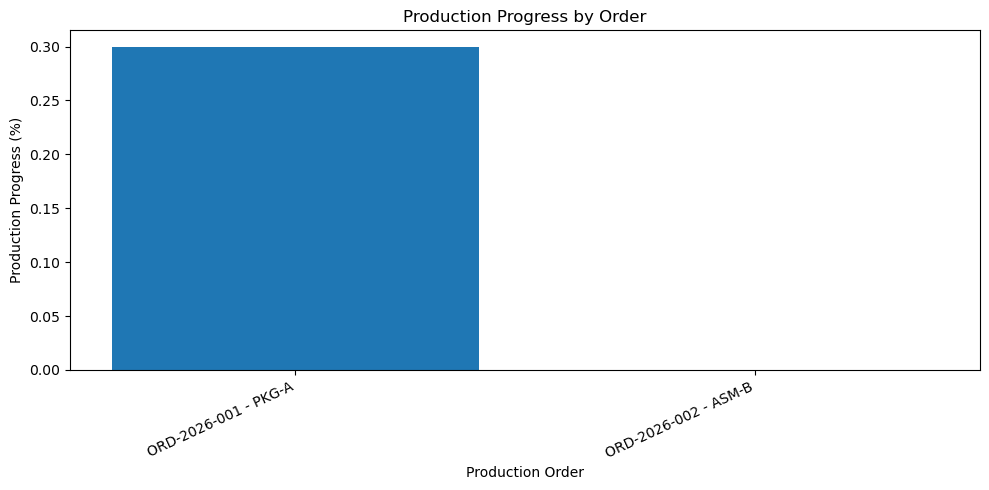

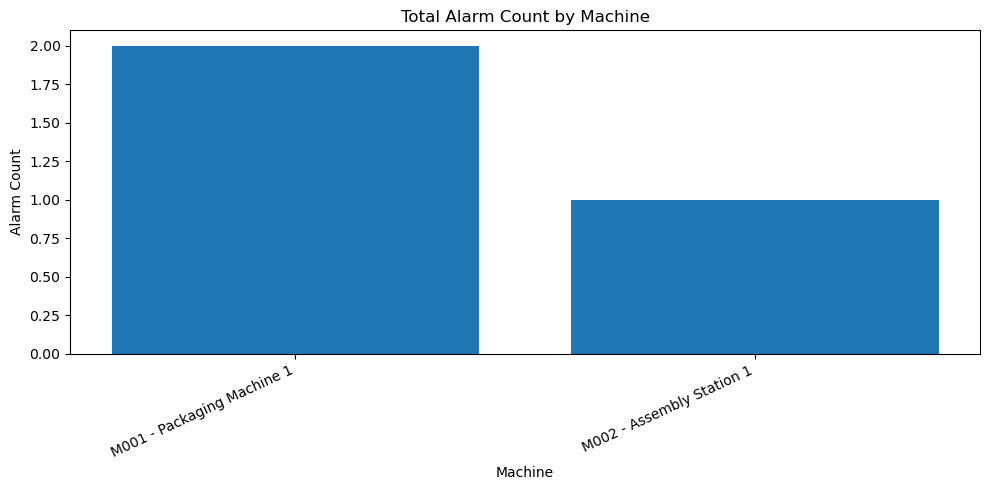

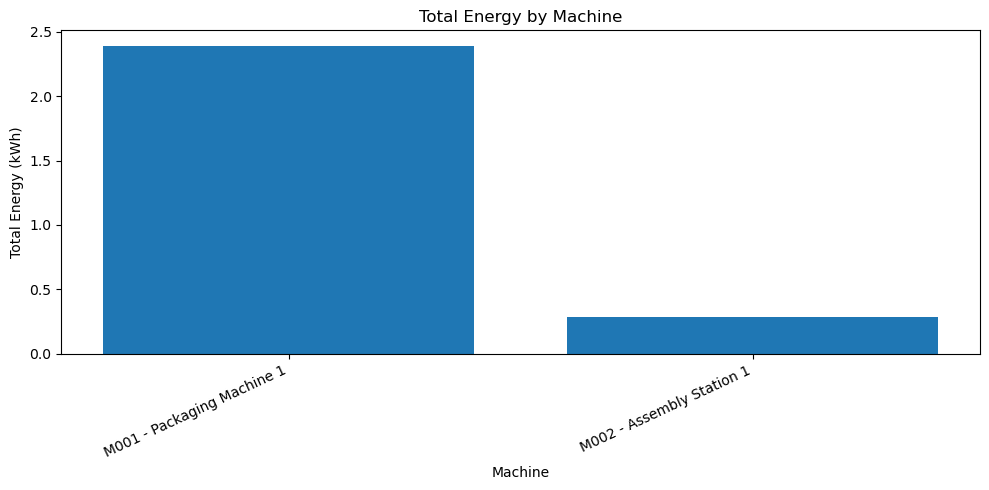

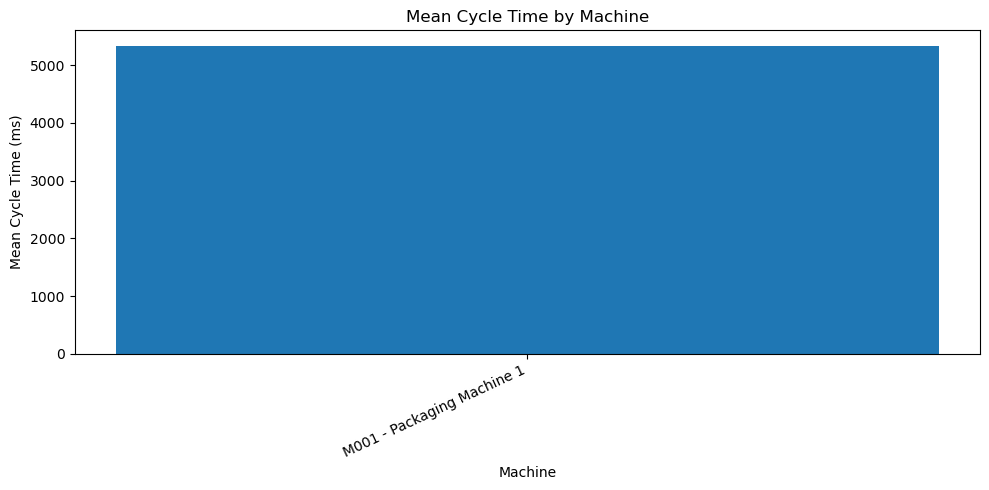

Basic visualizations created successfully.

Figures created: 4
Visualization export summary file:
outputs\tables\visualization_export_summary.csv

Generated figure files:


,figure_name,relative_path,file_exists,file_size_bytes,is_valid_figure
0,production_progress_by_order.png,outputs\figures\production_progress_by_order.png,True,48254,True
1,alarm_count_by_machine.png,outputs\figures\alarm_count_by_machine.png,True,52061,True
2,total_energy_by_machine.png,outputs\figures\total_energy_by_machine.png,True,47895,True
3,mean_cycle_time_by_machine.png,outputs\figures\mean_cycle_time_by_machine.png,True,41615,True


In [13]:
# ---------------------------------------------------------
# Create basic visualizations
# ---------------------------------------------------------

import matplotlib.pyplot as plt
from IPython.display import Image as NotebookImage


required_visualization_variables = [
    "machine_operational_view",
    "production_order_view",
]

missing_visualization_variables = [
    variable_name
    for variable_name in required_visualization_variables
    if variable_name not in globals()
]

if missing_visualization_variables:
    raise RuntimeError(
        "The following required variables are missing: "
        f"{missing_visualization_variables}. "
        "Run the machine-level and production-order summary sections first."
    )


# ---------------------------------------------------------
# 1. Prepare output folder
# ---------------------------------------------------------

output_figures_dir = PROJECT_ROOT / "outputs" / "figures"
output_figures_dir.mkdir(
    parents=True,
    exist_ok=True,
)


# ---------------------------------------------------------
# 2. Prepare clean chart datasets
# ---------------------------------------------------------

machine_chart_data = machine_operational_view.copy()
order_chart_data = production_order_view.copy()

machine_chart_data["machine_label"] = (
    machine_chart_data["machine_id"].astype(str)
    + " - "
    + machine_chart_data["machine_name"].astype(str)
)

order_chart_data["order_label"] = (
    order_chart_data["order_number"].astype(str)
    + " - "
    + order_chart_data["product_code"].astype(str)
)


# ---------------------------------------------------------
# 3. Production progress by order
# ---------------------------------------------------------

production_progress_chart_path = (
    output_figures_dir / "production_progress_by_order.png"
)

production_progress_chart_data = order_chart_data[
    [
        "order_label",
        "production_progress_percent",
    ]
].copy()

production_progress_chart_data["production_progress_percent"] = (
    pd.to_numeric(
        production_progress_chart_data["production_progress_percent"],
        errors="coerce",
    )
    .fillna(0)
)

plt.figure(figsize=(10, 5))
plt.bar(
    production_progress_chart_data["order_label"],
    production_progress_chart_data["production_progress_percent"],
)
plt.title("Production Progress by Order")
plt.xlabel("Production Order")
plt.ylabel("Production Progress (%)")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.savefig(
    production_progress_chart_path,
    dpi=150,
    bbox_inches="tight",
)
plt.show()


# ---------------------------------------------------------
# 4. Alarm count by machine
# ---------------------------------------------------------

alarm_count_chart_path = (
    output_figures_dir / "alarm_count_by_machine.png"
)

alarm_count_chart_data = machine_chart_data[
    [
        "machine_label",
        "total_alarm_count",
    ]
].copy()

alarm_count_chart_data["total_alarm_count"] = (
    pd.to_numeric(
        alarm_count_chart_data["total_alarm_count"],
        errors="coerce",
    )
    .fillna(0)
)

plt.figure(figsize=(10, 5))
plt.bar(
    alarm_count_chart_data["machine_label"],
    alarm_count_chart_data["total_alarm_count"],
)
plt.title("Total Alarm Count by Machine")
plt.xlabel("Machine")
plt.ylabel("Alarm Count")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.savefig(
    alarm_count_chart_path,
    dpi=150,
    bbox_inches="tight",
)
plt.show()


# ---------------------------------------------------------
# 5. Total energy by machine
# ---------------------------------------------------------

energy_chart_path = (
    output_figures_dir / "total_energy_by_machine.png"
)

energy_chart_data = machine_chart_data[
    [
        "machine_label",
        "total_energy_kwh",
    ]
].copy()

energy_chart_data["total_energy_kwh"] = (
    pd.to_numeric(
        energy_chart_data["total_energy_kwh"],
        errors="coerce",
    )
    .fillna(0)
)

plt.figure(figsize=(10, 5))
plt.bar(
    energy_chart_data["machine_label"],
    energy_chart_data["total_energy_kwh"],
)
plt.title("Total Energy by Machine")
plt.xlabel("Machine")
plt.ylabel("Total Energy (kWh)")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.savefig(
    energy_chart_path,
    dpi=150,
    bbox_inches="tight",
)
plt.show()


# ---------------------------------------------------------
# 6. Mean cycle time by machine
# ---------------------------------------------------------

cycle_time_chart_path = (
    output_figures_dir / "mean_cycle_time_by_machine.png"
)

cycle_time_chart_data = machine_chart_data[
    [
        "machine_label",
        "mean_cycle_time_ms",
    ]
].copy()

cycle_time_chart_data["mean_cycle_time_ms"] = pd.to_numeric(
    cycle_time_chart_data["mean_cycle_time_ms"],
    errors="coerce",
)

cycle_time_chart_data = cycle_time_chart_data.dropna(
    subset=["mean_cycle_time_ms"]
)

if cycle_time_chart_data.empty:
    print("No valid mean cycle-time data available for visualization.")
else:
    plt.figure(figsize=(10, 5))
    plt.bar(
        cycle_time_chart_data["machine_label"],
        cycle_time_chart_data["mean_cycle_time_ms"],
    )
    plt.title("Mean Cycle Time by Machine")
    plt.xlabel("Machine")
    plt.ylabel("Mean Cycle Time (ms)")
    plt.xticks(rotation=25, ha="right")
    plt.tight_layout()
    plt.savefig(
        cycle_time_chart_path,
        dpi=150,
        bbox_inches="tight",
    )
    plt.show()


# ---------------------------------------------------------
# 7. Validate generated figure files
# ---------------------------------------------------------

expected_figure_files = [
    production_progress_chart_path,
    alarm_count_chart_path,
    energy_chart_path,
    cycle_time_chart_path,
]

visualization_export_records = []

for figure_path in expected_figure_files:
    figure_exists = figure_path.exists()
    figure_size_bytes = figure_path.stat().st_size if figure_exists else 0

    visualization_export_records.append(
        {
            "figure_name": figure_path.name,
            "relative_path": str(figure_path.relative_to(PROJECT_ROOT)),
            "file_exists": figure_exists,
            "file_size_bytes": figure_size_bytes,
            "is_valid_figure": figure_exists and figure_size_bytes > 0,
        }
    )

visualization_export_summary = pd.DataFrame(visualization_export_records)

visualization_export_summary_path = (
    PROJECT_ROOT / "outputs" / "tables" / "visualization_export_summary.csv"
)

visualization_export_summary.to_csv(
    visualization_export_summary_path,
    index=False,
)


failed_figures = visualization_export_summary[
    visualization_export_summary["is_valid_figure"] == False
].copy()

if not failed_figures.empty:
    display(visualization_export_summary)

    raise RuntimeError(
        "One or more figure files failed validation. "
        "Review the visualization export summary table above."
    )


print("Basic visualizations created successfully.")
print()
print("Figures created:", len(visualization_export_summary))
print("Visualization export summary file:")
print(visualization_export_summary_path.relative_to(PROJECT_ROOT))

print()
print("Generated figure files:")
display(visualization_export_summary)

## 13. Analysis Summary and Engineering Interpretation

This section summarizes the main results of the production-data analysis workflow.

The goal is to combine the key findings from the table validation, cycle-time analysis, alarm analysis, energy review, machine-level summary, production-order summary, and exported visualizations into one clear engineering interpretation.

The summary focuses on what the sample dataset demonstrates technically: how production data can be loaded from SQLite, validated, transformed into analysis views, exported as CSV files, and visualized for reporting.

The section also separates overall production progress from mean order-level progress. This avoids confusing a total produced-versus-planned ratio with the average of individual order progress percentages.

The results are based on generated sample data and should be interpreted as a workflow demonstration, not as a real production-performance assessment.


In [14]:
# ---------------------------------------------------------
# Create final analysis summary and engineering interpretation
# ---------------------------------------------------------

from textwrap import dedent


required_interpretation_variables = [
    "machine_operational_view",
    "production_order_view",
    "export_validation_summary",
    "visualization_export_summary",
]

missing_interpretation_variables = [
    variable_name
    for variable_name in required_interpretation_variables
    if variable_name not in globals()
]

if missing_interpretation_variables:
    raise RuntimeError(
        "The following required variables are missing: "
        f"{missing_interpretation_variables}. "
        "Run the previous analysis, export-validation, and visualization sections first."
    )


# ---------------------------------------------------------
# 1. Prepare working copies
# ---------------------------------------------------------

machine_summary = machine_operational_view.copy()
order_summary = production_order_view.copy()
csv_validation_summary = export_validation_summary.copy()
figure_validation_summary = visualization_export_summary.copy()


# ---------------------------------------------------------
# 2. Convert important numeric columns
# ---------------------------------------------------------

machine_numeric_columns = [
    "is_active",
    "production_cycle_count",
    "total_produced_quantity",
    "mean_cycle_time_ms",
    "max_cycle_time_ms",
    "total_alarm_count",
    "critical_alarm_count",
    "warning_alarm_count",
    "acknowledged_alarm_count",
    "total_alarm_duration_minutes",
    "max_alarm_duration_minutes",
    "energy_reading_count",
    "mean_power_kw",
    "max_power_kw",
    "total_energy_kwh",
    "machine_event_count",
    "fault_event_count",
    "state_change_event_count",
    "operator_action_event_count",
]

order_numeric_columns = [
    "planned_quantity",
    "total_produced_quantity",
    "production_cycle_count",
    "mean_cycle_time_ms",
    "max_cycle_time_ms",
    "total_alarm_count",
    "critical_alarm_count",
    "warning_alarm_count",
    "acknowledged_alarm_count",
    "total_alarm_duration_minutes",
    "max_alarm_duration_minutes",
    "energy_reading_count",
    "mean_power_kw",
    "max_power_kw",
    "total_energy_kwh",
    "machine_event_count",
    "fault_event_count",
    "state_change_event_count",
    "operator_action_event_count",
    "production_progress_percent",
]

for column_name in machine_numeric_columns:
    if column_name in machine_summary.columns:
        machine_summary[column_name] = pd.to_numeric(
            machine_summary[column_name],
            errors="coerce",
        )

for column_name in order_numeric_columns:
    if column_name in order_summary.columns:
        order_summary[column_name] = pd.to_numeric(
            order_summary[column_name],
            errors="coerce",
        )


# ---------------------------------------------------------
# 3. Helper functions
# ---------------------------------------------------------

def safe_sum(dataframe, column_name):
    if column_name not in dataframe.columns:
        return 0

    values = pd.to_numeric(
        dataframe[column_name],
        errors="coerce",
    )

    return values.sum(skipna=True)


def safe_mean(dataframe, column_name):
    if column_name not in dataframe.columns:
        return pd.NA

    values = pd.to_numeric(
        dataframe[column_name],
        errors="coerce",
    ).dropna()

    return values.mean() if not values.empty else pd.NA


def safe_max(dataframe, column_name):
    if column_name not in dataframe.columns:
        return pd.NA

    values = pd.to_numeric(
        dataframe[column_name],
        errors="coerce",
    ).dropna()

    return values.max() if not values.empty else pd.NA


def format_optional_number(value, decimals=2):
    if pd.isna(value):
        return "Not available"

    return f"{value:.{decimals}f}"


def get_top_record_label(dataframe, sort_column, label_columns, decimals=2):
    if dataframe.empty or sort_column not in dataframe.columns:
        return "Not available"

    valid_records = dataframe.dropna(subset=[sort_column]).copy()

    if valid_records.empty:
        return "Not available"

    top_record = valid_records.sort_values(
        by=sort_column,
        ascending=False,
    ).iloc[0]

    label_parts = []

    for column_name in label_columns:
        if column_name in top_record.index and pd.notna(top_record[column_name]):
            label_parts.append(str(top_record[column_name]))

    if label_parts:
        label = " - ".join(label_parts)
    else:
        label = "Unnamed record"

    return f"{label} ({top_record[sort_column]:.{decimals}f})"


# ---------------------------------------------------------
# 4. Calculate project-level metrics
# ---------------------------------------------------------

machine_count = len(machine_summary)
production_order_count = len(order_summary)

if "is_active" in machine_summary.columns:
    active_machine_count = int(
        machine_summary["is_active"]
        .fillna(0)
        .astype(int)
        .sum()
    )
else:
    active_machine_count = pd.NA

total_planned_quantity = safe_sum(order_summary, "planned_quantity")
total_produced_quantity = safe_sum(order_summary, "total_produced_quantity")

overall_production_progress_percent = (
    total_produced_quantity / total_planned_quantity * 100
    if pd.notna(total_planned_quantity) and total_planned_quantity > 0
    else pd.NA
)

mean_order_progress_percent = safe_mean(
    order_summary,
    "production_progress_percent",
)

total_alarm_count = safe_sum(machine_summary, "total_alarm_count")
critical_alarm_count = safe_sum(machine_summary, "critical_alarm_count")
warning_alarm_count = safe_sum(machine_summary, "warning_alarm_count")

total_energy_kwh = safe_sum(machine_summary, "total_energy_kwh")

mean_cycle_time_ms = safe_mean(machine_summary, "mean_cycle_time_ms")
max_cycle_time_ms = safe_max(machine_summary, "max_cycle_time_ms")

csv_files_checked = len(csv_validation_summary)
valid_csv_files = int(csv_validation_summary["is_valid_export"].sum())

figure_files_checked = len(figure_validation_summary)
valid_figure_files = int(figure_validation_summary["is_valid_figure"].sum())

machine_highest_production = get_top_record_label(
    machine_summary,
    "total_produced_quantity",
    ["machine_id", "machine_name"],
    decimals=0,
)

machine_highest_alarm_count = get_top_record_label(
    machine_summary,
    "total_alarm_count",
    ["machine_id", "machine_name"],
    decimals=0,
)

machine_highest_energy = get_top_record_label(
    machine_summary,
    "total_energy_kwh",
    ["machine_id", "machine_name"],
    decimals=2,
)

order_highest_progress = get_top_record_label(
    order_summary,
    "production_progress_percent",
    ["order_number", "product_code"],
    decimals=2,
)


# ---------------------------------------------------------
# 5. Build final metric summary table
# ---------------------------------------------------------

analysis_metric_records = [
    {
        "metric": "machines_analyzed",
        "value": machine_count,
        "interpretation": "Number of machine master records included in the analysis.",
    },
    {
        "metric": "active_machines",
        "value": active_machine_count,
        "interpretation": "Number of machines marked as active in the sample dataset.",
    },
    {
        "metric": "production_orders_analyzed",
        "value": production_order_count,
        "interpretation": "Number of production orders included in the summary view.",
    },
    {
        "metric": "total_planned_quantity",
        "value": round(total_planned_quantity, 2),
        "interpretation": "Total planned production quantity across all sample orders.",
    },
    {
        "metric": "total_produced_quantity",
        "value": round(total_produced_quantity, 2),
        "interpretation": "Total produced quantity recorded in the sample cycle data.",
    },
    {
        "metric": "overall_production_progress_percent",
        "value": format_optional_number(overall_production_progress_percent, 2),
        "interpretation": "Overall production progress calculated as total produced quantity divided by total planned quantity across all sample orders.",
    },
    {
        "metric": "mean_order_progress_percent",
        "value": format_optional_number(mean_order_progress_percent, 2),
        "interpretation": "Average of order-level production progress percentages. This is different from the overall produced/planned ratio.",
    },
    {
        "metric": "total_alarm_count",
        "value": int(total_alarm_count),
        "interpretation": "Total number of alarm records summarized across machines.",
    },
    {
        "metric": "critical_alarm_count",
        "value": int(critical_alarm_count),
        "interpretation": "Number of alarms classified as critical.",
    },
    {
        "metric": "warning_alarm_count",
        "value": int(warning_alarm_count),
        "interpretation": "Number of alarms classified as warning.",
    },
    {
        "metric": "total_energy_kwh",
        "value": round(total_energy_kwh, 2),
        "interpretation": "Total recorded energy consumption in the sample dataset.",
    },
    {
        "metric": "mean_cycle_time_ms",
        "value": format_optional_number(mean_cycle_time_ms, 2),
        "interpretation": "Average machine-level mean cycle time where valid cycle data exists.",
    },
    {
        "metric": "max_cycle_time_ms",
        "value": format_optional_number(max_cycle_time_ms, 2),
        "interpretation": "Maximum machine-level cycle time observed in the summarized sample data.",
    },
    {
        "metric": "valid_csv_exports",
        "value": f"{valid_csv_files} of {csv_files_checked}",
        "interpretation": "Number of exported CSV summary files that passed validation.",
    },
    {
        "metric": "valid_figure_exports",
        "value": f"{valid_figure_files} of {figure_files_checked}",
        "interpretation": "Number of exported PNG figure files that passed validation.",
    },
]

analysis_metric_summary = pd.DataFrame(analysis_metric_records)


# ---------------------------------------------------------
# 6. Build engineering interpretation text
# ---------------------------------------------------------

engineering_interpretation = dedent(
    f"""
    # Analysis Summary and Engineering Interpretation

    ## Project Scope

    This project demonstrates a simplified production-data analysis workflow using a SQLite database, Python, pandas, and Matplotlib.

    The workflow loads relational production data, validates table structure, analyzes cycle records, summarizes alarms, reviews energy readings around a selected fault window, creates machine-level and production-order-level summary views, exports reusable CSV files, and generates basic visualizations.

    ## Sample Scenario

    The dataset is intentionally small and synthetic. It contains two machines and two production orders. Machine M001 represents a packaging machine with recorded production cycles, alarms, energy readings, and machine-event logs. Machine M002 represents an assembly station with limited operational activity in the sample data.

    ALM-304 is used as the main critical alarm event for the fault-window energy analysis. The analysis compares alarm timing and energy readings to demonstrate temporal association only. It does not prove that the alarm caused the observed energy change.

    ## Main Results

    - Machines analyzed: {machine_count}
    - Active machines: {active_machine_count}
    - Production orders analyzed: {production_order_count}
    - Total planned quantity: {total_planned_quantity:.2f}
    - Total produced quantity: {total_produced_quantity:.2f}
    - Overall production progress: {format_optional_number(overall_production_progress_percent, 2)}%
    - Mean order-level production progress: {format_optional_number(mean_order_progress_percent, 2)}%
    - Total alarm count: {int(total_alarm_count)}
    - Critical alarm count: {int(critical_alarm_count)}
    - Warning alarm count: {int(warning_alarm_count)}
    - Total recorded energy: {total_energy_kwh:.2f} kWh
    - Machine with highest produced quantity: {machine_highest_production}
    - Machine with highest alarm count: {machine_highest_alarm_count}
    - Machine with highest recorded energy: {machine_highest_energy}
    - Production order with highest progress: {order_highest_progress}

    ## Production Progress Metric Definition

    The project separates overall production progress from mean order-level progress.

    Overall production progress is calculated as total produced quantity divided by total planned quantity across all orders.

    Mean order-level progress is calculated as the average of each order's individual progress percentage.

    These values can differ, especially when orders have different planned quantities. In this sample dataset, the progress values are intentionally very low because only a few production cycles are recorded. They demonstrate the calculation workflow and should not be interpreted as real production performance.

    ## Engineering Interpretation

    The analysis shows how production data from several related tables can be transformed into reusable operational views.

    The machine-level summary combines machine master data with production-cycle counts, produced quantity, alarm counts, energy readings, and machine-event activity. This provides a compact view for comparing machine activity inside the sample dataset.

    The production-order summary combines order data with cycle records, alarm records, energy readings, machine events, and machine master data. This makes it possible to review production progress and operational context at order level.

    The alarm analysis identifies alarm severity, category, acknowledgement status, and alarm duration. In the sample data, one critical alarm is present. This can be used to demonstrate how alarm records can be filtered and connected to affected machines.

    The energy analysis around the selected ALM-304 fault window shows a temporal relationship between an alarm interval and nearby energy readings. This is useful for investigating production behavior around fault periods. However, the result shows association only. It does not prove that the alarm caused the observed energy change.

    The visualization section creates simple charts for production progress, alarm count, total energy, and mean cycle time. These charts provide a compact visual overview of the generated sample dataset and are saved as reusable PNG files.

    ## Validation Result

    The exported CSV files were checked for file existence, file size, row count, and required columns.

    Valid CSV exports: {valid_csv_files} of {csv_files_checked}

    The exported visualization files were checked for file existence and file size.

    Valid figure exports: {valid_figure_files} of {figure_files_checked}

    ## Limitations

    The dataset is intentionally small and generated for demonstration purposes. The results should not be interpreted as a real production benchmark.

    Alarm duration is not automatically downtime. A real downtime calculation would require machine-state data, production-state information, downtime classification logic, and overlap-aware interval handling.

    A power change near an alarm window shows temporal association only. It does not prove causation without additional machine-state, control-sequence, operator-action, and process-context data.

    A real industrial analysis would require more historical data, real machine-state information, downtime classification, product type, shift context, operator actions, quality results, maintenance records, and validated production targets.

    ## Conclusion

    This project demonstrates the structure of an industrial production-data analysis workflow. It shows how relational production data can be loaded, validated, transformed, summarized, exported, visualized, and interpreted in a clear IT/OT reporting context.
    """
).strip()


# ---------------------------------------------------------
# 7. Save final summary outputs
# ---------------------------------------------------------

output_tables_dir = PROJECT_ROOT / "outputs" / "tables"
output_tables_dir.mkdir(
    parents=True,
    exist_ok=True,
)

docs_dir = PROJECT_ROOT / "docs"
docs_dir.mkdir(
    parents=True,
    exist_ok=True,
)

analysis_metric_summary_path = (
    output_tables_dir / "analysis_metric_summary.csv"
)

analysis_summary_markdown_path = (
    docs_dir / "analysis_summary.md"
)

analysis_metric_summary.to_csv(
    analysis_metric_summary_path,
    index=False,
)

analysis_summary_markdown_path.write_text(
    engineering_interpretation,
    encoding="utf-8",
)


# ---------------------------------------------------------
# 8. Validate final summary outputs
# ---------------------------------------------------------

final_summary_outputs = [
    analysis_metric_summary_path,
    analysis_summary_markdown_path,
]

final_summary_validation_records = []

for output_path in final_summary_outputs:
    output_exists = output_path.exists()
    output_size_bytes = output_path.stat().st_size if output_exists else 0

    final_summary_validation_records.append(
        {
            "output_file": output_path.name,
            "relative_path": str(output_path.relative_to(PROJECT_ROOT)),
            "file_exists": output_exists,
            "file_size_bytes": output_size_bytes,
            "is_valid_output": output_exists and output_size_bytes > 0,
        }
    )

final_summary_validation = pd.DataFrame(final_summary_validation_records)

failed_final_outputs = final_summary_validation[
    final_summary_validation["is_valid_output"] == False
].copy()

if not failed_final_outputs.empty:
    display(final_summary_validation)

    raise RuntimeError(
        "One or more final summary files failed validation. "
        "Review the final summary validation table above."
    )


print("Final analysis summary created successfully.")
print()
print("Metric summary file:")
print(analysis_metric_summary_path.relative_to(PROJECT_ROOT))
print()
print("Markdown summary file:")
print(analysis_summary_markdown_path.relative_to(PROJECT_ROOT))

print()
print("Analysis metric summary:")
display(analysis_metric_summary)

print()
print("Final summary output validation:")
display(final_summary_validation)


Final analysis summary created successfully.

Metric summary file:
outputs\tables\analysis_metric_summary.csv

Markdown summary file:
docs\analysis_summary.md

Analysis metric summary:


,metric,value,interpretation
0,machines_analyzed,2,Number of machine master records included in t...
1,active_machines,2,Number of machines marked as active in the sam...
2,production_orders_analyzed,2,Number of production orders included in the su...
3,total_planned_quantity,1500,Total planned production quantity across all s...
4,total_produced_quantity,3,Total produced quantity recorded in the sample...
5,overall_production_progress_percent,0.20,Overall production progress calculated as tota...
6,mean_order_progress_percent,0.15,Average of order-level production progress per...
7,total_alarm_count,3,Total number of alarm records summarized acros...
8,critical_alarm_count,1,Number of alarms classified as critical.
9,warning_alarm_count,2,Number of alarms classified as warning.



Final summary output validation:


,output_file,relative_path,file_exists,file_size_bytes,is_valid_output
0,analysis_metric_summary.csv,outputs\tables\analysis_metric_summary.csv,True,1427,True
1,analysis_summary.md,docs\analysis_summary.md,True,5276,True
